# Meme Stock Outage Event Study: GME & AMC — 5-Min & 10-Min Bar Frequencies

**Objective:** Replicate the FF4 event study figures at **5-minute** and **10-minute** bar
frequencies, using the multi-model excess return CSVs produced by `excess_return_multi_model.ipynb`.

**Prerequisite:** Run `excess_return_multi_model.ipynb` first to generate the input CSVs.

**Events analyzed:**

| Event | Window | Duration | Period |
|-------|--------|----------|--------|
| Outage 1 | Jan 27, 11:29–13:40 | 131 min | Pre-Ban |
| Outage 2 | Jan 27, 16:03–17:01 | 58 min  | Pre-Ban |
| Outage 3 | Jan 28, 08:44–10:51 | 127 min | Post-Ban |
| Outage 4 | Jan 28, 19:10–21:00 | 110 min | Post-Ban |

**Models used in figures:** CAPM (all hours), FF4 (trading hours; CAPM fallback after hours)

**Output figures saved to:**
- `output/multi_freq/figures/5min/`
- `output/multi_freq/figures/10min/`

---
## 1. Setup & Configuration

In [1]:
import pathlib
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = pathlib.Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "Minute price and exceed return" / "output_data"
OUTPUT_DIR   = pathlib.Path.cwd() / "output" / "multi_freq"
FIG_BASE     = OUTPUT_DIR / "figures"

for freq in ["5min", "10min"]:
    for sym in ["gme", "amc"]:
        (FIG_BASE / freq / sym).mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ── Bar frequencies to analyze ─────────────────────────────────────────────────
FREQS = ["5min", "10min"]

# ── Stock definitions ──────────────────────────────────────────────────────────
STOCKS = {
    "GME": {"price_col": "price", "return_col": "return"},
    "AMC": {"price_col": "price", "return_col": "return"},
}

# ── Outage events ──────────────────────────────────────────────────────────────
ROBINHOOD_BAN = pd.Timestamp("2021-01-28 09:30:00")

OUTAGE_EVENTS = [
    {"name": "Outage 1 (Pre-Ban)",  "start": pd.Timestamp("2021-01-27 11:29:00"), "end": pd.Timestamp("2021-01-27 13:40:00")},
    {"name": "Outage 2 (Pre-Ban)",  "start": pd.Timestamp("2021-01-27 16:03:00"), "end": pd.Timestamp("2021-01-27 17:01:00")},
    {"name": "Outage 3 (Post-Ban)", "start": pd.Timestamp("2021-01-28 08:44:00"), "end": pd.Timestamp("2021-01-28 10:51:00")},
    {"name": "Outage 4 (Post-Ban)", "start": pd.Timestamp("2021-01-28 19:10:00"), "end": pd.Timestamp("2021-01-28 21:00:00")},
]
for evt in OUTAGE_EVENTS:
    mid = evt["start"] + (evt["end"] - evt["start"]) / 2
    evt["pre_ban"] = mid < ROBINHOOD_BAN
    evt["duration_minutes"] = int((evt["end"] - evt["start"]).total_seconds() / 60)

# ── Estimation window ──────────────────────────────────────────────────────────
# [-120, -2]: end 2 trading days before first outage (matches FF4 notebook)
ESTIMATION_WINDOW_DAYS = 120
ESTIMATION_LAG_DAYS    = 2
FIRST_OUTAGE_START     = OUTAGE_EVENTS[0]["start"]
ESTIMATION_END         = FIRST_OUTAGE_START - timedelta(days=ESTIMATION_LAG_DAYS)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman"],
    "font.size":        12,
    "axes.linewidth":   1.2,
    "grid.alpha":       0.3,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "figure.dpi":       150,
    "savefig.bbox":     "tight",
    "savefig.dpi":      150,
})

PRE_BAN_COLOR  = "#D32F2F"  # red
POST_BAN_COLOR = "#1976D2"  # blue

print(f"Output directory: {OUTPUT_DIR}")
print(f"Frequencies to plot: {FREQS}")
print(f"Estimation window: {ESTIMATION_END - timedelta(days=ESTIMATION_WINDOW_DAYS)} → {ESTIMATION_END}")

Output directory: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/multi_freq
Frequencies to plot: ['5min', '10min']
Estimation window: 2020-09-27 11:29:00 → 2021-01-25 11:29:00


---
## 2. Load Multi-Model CSVs

In [2]:
def load_multi_model(symbol, freq_name):
    """
    Load the multi-model excess return CSV for a given stock and frequency.
    Generated by excess_return_multi_model.ipynb.
    """
    path = DATA_DIR / f"{symbol}-{freq_name}-multi-model-excess-return.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing: {path}\n"
            "Run excess_return_multi_model.ipynb first to generate input CSVs."
        )
    df = (
        pd.read_csv(path, parse_dates=["datetime"])
        .drop_duplicates("datetime")
        .sort_values("datetime")
        .set_index("datetime")
    )
    return df


# Load all four datasets
data = {}
for freq in FREQS:
    data[freq] = {}
    for sym in ["GME", "AMC"]:
        data[freq][sym] = load_multi_model(sym, freq)
        print(f"{sym} {freq}: {len(data[freq][sym]):,} bars "
              f"| {data[freq][sym].index.min()} → {data[freq][sym].index.max()}")

GME 5min: 51,744 bars | 2020-11-02 04:00:00 → 2021-04-30 19:55:00
AMC 5min: 51,744 bars | 2020-11-02 04:00:00 → 2021-04-30 19:55:00
GME 10min: 25,872 bars | 2020-11-02 04:00:00 → 2021-04-30 19:50:00
AMC 10min: 25,872 bars | 2020-11-02 04:00:00 → 2021-04-30 19:50:00


---
## 3. Event Window CAR Calculation

For each outage window, extract the event data and compute:
- **CAPM CAR** (all bars, including after-hours)
- **FF4 CAR** (trading-hours bars use full FF4 model; after-hours bars fall back to CAPM)

The FF4 fallback mirrors the approach in `meme_stock_outage_ff4.ipynb`.

In [3]:
def calculate_event_car(df, event, symbol, pre_period_hours=1):
    """
    Extract event window data (including a pre-period) and compute per-bar
    CARs for CAPM and FF4.

    The data window starts `pre_period_hours` before the outage start. CARs
    are normalized so that CAR = 0 at event_start, allowing pre-trend
    inspection without affecting the post-event metrics.

    FF4: uses AR_ff4 where available; falls back to AR_capm after hours.
    CAPM: uses AR_capm throughout.

    Returns a dict with summary metrics and the event_data DataFrame,
    or None if no bars fall in the event window.
    """
    event_start        = event["start"]
    event_end_extended = event["end"] + timedelta(hours=2)
    pre_period_start   = event_start - timedelta(hours=pre_period_hours)

    ed = df.loc[pre_period_start:event_end_extended].copy()
    if ed.empty:
        return None

    # FF4 CAR: use FF4 AR where factors available, else CAPM AR
    ff4_available   = ed["AR_ff4"].notna()
    ar_ff4_hybrid   = ed["AR_ff4"].where(ff4_available, ed["AR_capm"])

    # Cumulative sums from pre-period start
    car_ff4_raw  = ar_ff4_hybrid.cumsum()
    car_capm_raw = ed["AR_capm"].cumsum()

    # Normalize: CAR = 0 at event_start
    pre_mask = ed.index <= event_start
    offset_ff4  = car_ff4_raw.loc[pre_mask].iloc[-1]  if pre_mask.any() else 0.0
    offset_capm = car_capm_raw.loc[pre_mask].iloc[-1] if pre_mask.any() else 0.0

    ed["CAR_ff4_hybrid"]  = car_ff4_raw  - offset_ff4
    ed["CAR_capm_event"]  = car_capm_raw - offset_capm
    ed["ff4_available"]   = ff4_available
    ed["time_from_start"] = (ed.index - event_start).total_seconds() / 60

    def car_at(car_col, target_time):
        mask = ed.index <= target_time
        return ed.loc[mask, car_col].iloc[-1] if mask.any() else np.nan

    # Metrics at key time points
    for model, col in [("capm", "CAR_capm_event"), ("ff4", "CAR_ff4_hybrid")]:
        ed.attrs[f"car_30min_{model}"]      = car_at(col, event_start + timedelta(minutes=30))
        ed.attrs[f"car_1h_{model}"]         = car_at(col, event_start + timedelta(hours=1))
        ed.attrs[f"car_outage_end_{model}"] = car_at(col, event["end"])

    # Price change during outage
    outage_slice = df.loc[event_start:event["end"]]
    if len(outage_slice) >= 2:
        p_start = outage_slice["price"].iloc[0]
        p_end   = outage_slice["price"].iloc[-1]
        price_change_pct = (p_end - p_start) / p_start * 100
    else:
        price_change_pct = np.nan

    n_total    = len(ed.loc[event_start:event["end"]])
    n_ff4_bars = int(ed.loc[event_start:event["end"], "ff4_available"].sum())

    return {
        "event_name":        event["name"],
        "start_time":        event["start"],
        "end_time":          event["end"],
        "pre_period_start":  pre_period_start,
        "duration_minutes":  event["duration_minutes"],
        "pre_ban":           event["pre_ban"],
        "CAR_30min_capm":    ed.attrs["car_30min_capm"],
        "CAR_1h_capm":       ed.attrs["car_1h_capm"],
        "CAR_end_capm":      ed.attrs["car_outage_end_capm"],
        "CAR_30min_ff4":     ed.attrs["car_30min_ff4"],
        "CAR_1h_ff4":        ed.attrs["car_1h_ff4"],
        "CAR_end_ff4":       ed.attrs["car_outage_end_ff4"],
        "price_change_pct":  price_change_pct,
        "n_ff4_bars":        n_ff4_bars,
        "n_total_bars":      n_total,
        "event_data":        ed,
    }


# Run event study for all frequencies and stocks
all_results = {}
for freq in FREQS:
    all_results[freq] = {}
    for sym in ["GME", "AMC"]:
        results = []
        for evt in OUTAGE_EVENTS:
            r = calculate_event_car(data[freq][sym], evt, sym)
            if r:
                results.append(r)
        all_results[freq][sym] = results
        print(f"{sym} @ {freq}: {len(results)} events computed")


GME @ 5min: 4 events computed
AMC @ 5min: 4 events computed
GME @ 10min: 4 events computed
AMC @ 10min: 4 events computed


---
## 4. Results Summary Tables

In [4]:
def build_results_df(all_results, freq):
    rows = []
    for sym in ["GME", "AMC"]:
        for r in all_results[freq][sym]:
            rows.append({
                "Stock":          sym,
                "Event":          r["event_name"],
                "Pre-Ban":        r["pre_ban"],
                "CAR @30min (FF4)": r["CAR_30min_ff4"],
                "CAR @1h (FF4)":    r["CAR_1h_ff4"],
                "CAR @End (FF4)":   r["CAR_end_ff4"],
                "CAR @30min (CAPM)": r["CAR_30min_capm"],
                "CAR @End (CAPM)": r["CAR_end_capm"],
                "Price Chg %":    r["price_change_pct"],
                "FF4 bars/Total": f"{r['n_ff4_bars']}/{r['n_total_bars']}",
            })
    return pd.DataFrame(rows)


for freq in FREQS:
    print(f"\n{'='*70}")
    print(f"  Results @ {freq}")
    print(f"{'='*70}")
    df = build_results_df(all_results, freq)

    # Save CSV
    out_path = OUTPUT_DIR / f"car_results_{freq}.csv"
    df.to_csv(out_path, index=False)
    print(f"  Saved: {out_path.name}")

    fmt = {c: "{:.4f}" for c in df.columns if "CAR" in c}
    fmt["Price Chg %"] = "{:.2f}%"
    display(df.style.format(fmt).set_caption(f"FF4 Event Study Results @ {freq}"))


  Results @ 5min
  Saved: car_results_5min.csv


,Stock,Event,Pre-Ban,CAR @30min (FF4),CAR @1h (FF4),CAR @End (FF4),CAR @30min (CAPM),CAR @End (CAPM),Price Chg %,FF4 bars/Total
0,GME,Outage 1 (Pre-Ban),True,-0.1473,-0.1941,-0.1262,-0.1405,-0.1172,-11.49%,27/27
1,GME,Outage 2 (Pre-Ban),True,-0.0973,-0.1562,-0.1562,-0.0973,-0.1562,-4.08%,0/12
2,GME,Outage 3 (Post-Ban),False,-0.3492,-0.2129,-0.6092,-0.3492,-0.6433,-36.99%,17/26
3,GME,Outage 4 (Post-Ban),False,-0.0397,nan,nan,-0.0397,nan,nan%,0/23
4,AMC,Outage 1 (Pre-Ban),True,-0.2053,-0.2139,-0.0169,-0.1961,-0.0149,1.63%,27/27
5,AMC,Outage 2 (Pre-Ban),True,-0.2469,-0.2239,-0.2239,-0.2469,-0.2239,-3.40%,0/12
6,AMC,Outage 3 (Post-Ban),False,-0.2375,-0.0822,-0.6932,-0.2375,-0.7071,-43.25%,17/26
7,AMC,Outage 4 (Post-Ban),False,-0.0108,nan,nan,-0.0108,nan,nan%,0/23



  Results @ 10min
  Saved: car_results_10min.csv


,Stock,Event,Pre-Ban,CAR @30min (FF4),CAR @1h (FF4),CAR @End (FF4),CAR @30min (CAPM),CAR @End (CAPM),Price Chg %,FF4 bars/Total
0,GME,Outage 1 (Pre-Ban),True,-0.1453,-0.1915,-0.1130,-0.1386,-0.1018,-8.46%,14/14
1,GME,Outage 2 (Pre-Ban),True,0.0089,-0.0624,-0.0624,0.0089,-0.0624,-5.00%,0/6
2,GME,Outage 3 (Post-Ban),False,-0.3625,-0.0564,-0.6034,-0.3625,-0.6344,-14.67%,9/13
3,GME,Outage 4 (Post-Ban),False,-0.0605,nan,nan,-0.0605,nan,nan%,0/12
4,AMC,Outage 1 (Pre-Ban),True,-0.2023,-0.2113,-0.0072,-0.1932,-0.0054,4.51%,14/14
5,AMC,Outage 2 (Pre-Ban),True,-0.0955,-0.1128,-0.1128,-0.0955,-0.1128,-4.79%,0/6
6,AMC,Outage 3 (Post-Ban),False,-0.2172,-0.1670,-0.5125,-0.2172,-0.5261,-34.88%,9/13
7,AMC,Outage 4 (Post-Ban),False,-0.0164,nan,nan,-0.0164,nan,nan%,0/12


---
## 5. Per-Event Detail Plots

Two-panel figures for each outage × stock × frequency:
- **Top**: Stock price path through event window
- **Bottom**: FF4 CAR trajectory (with CAPM fallback for after-hours bars)

Outage window shaded; annotation shows final CAR and price change.


======================================================= 5min =======================================================

--- GME @ 5min ---


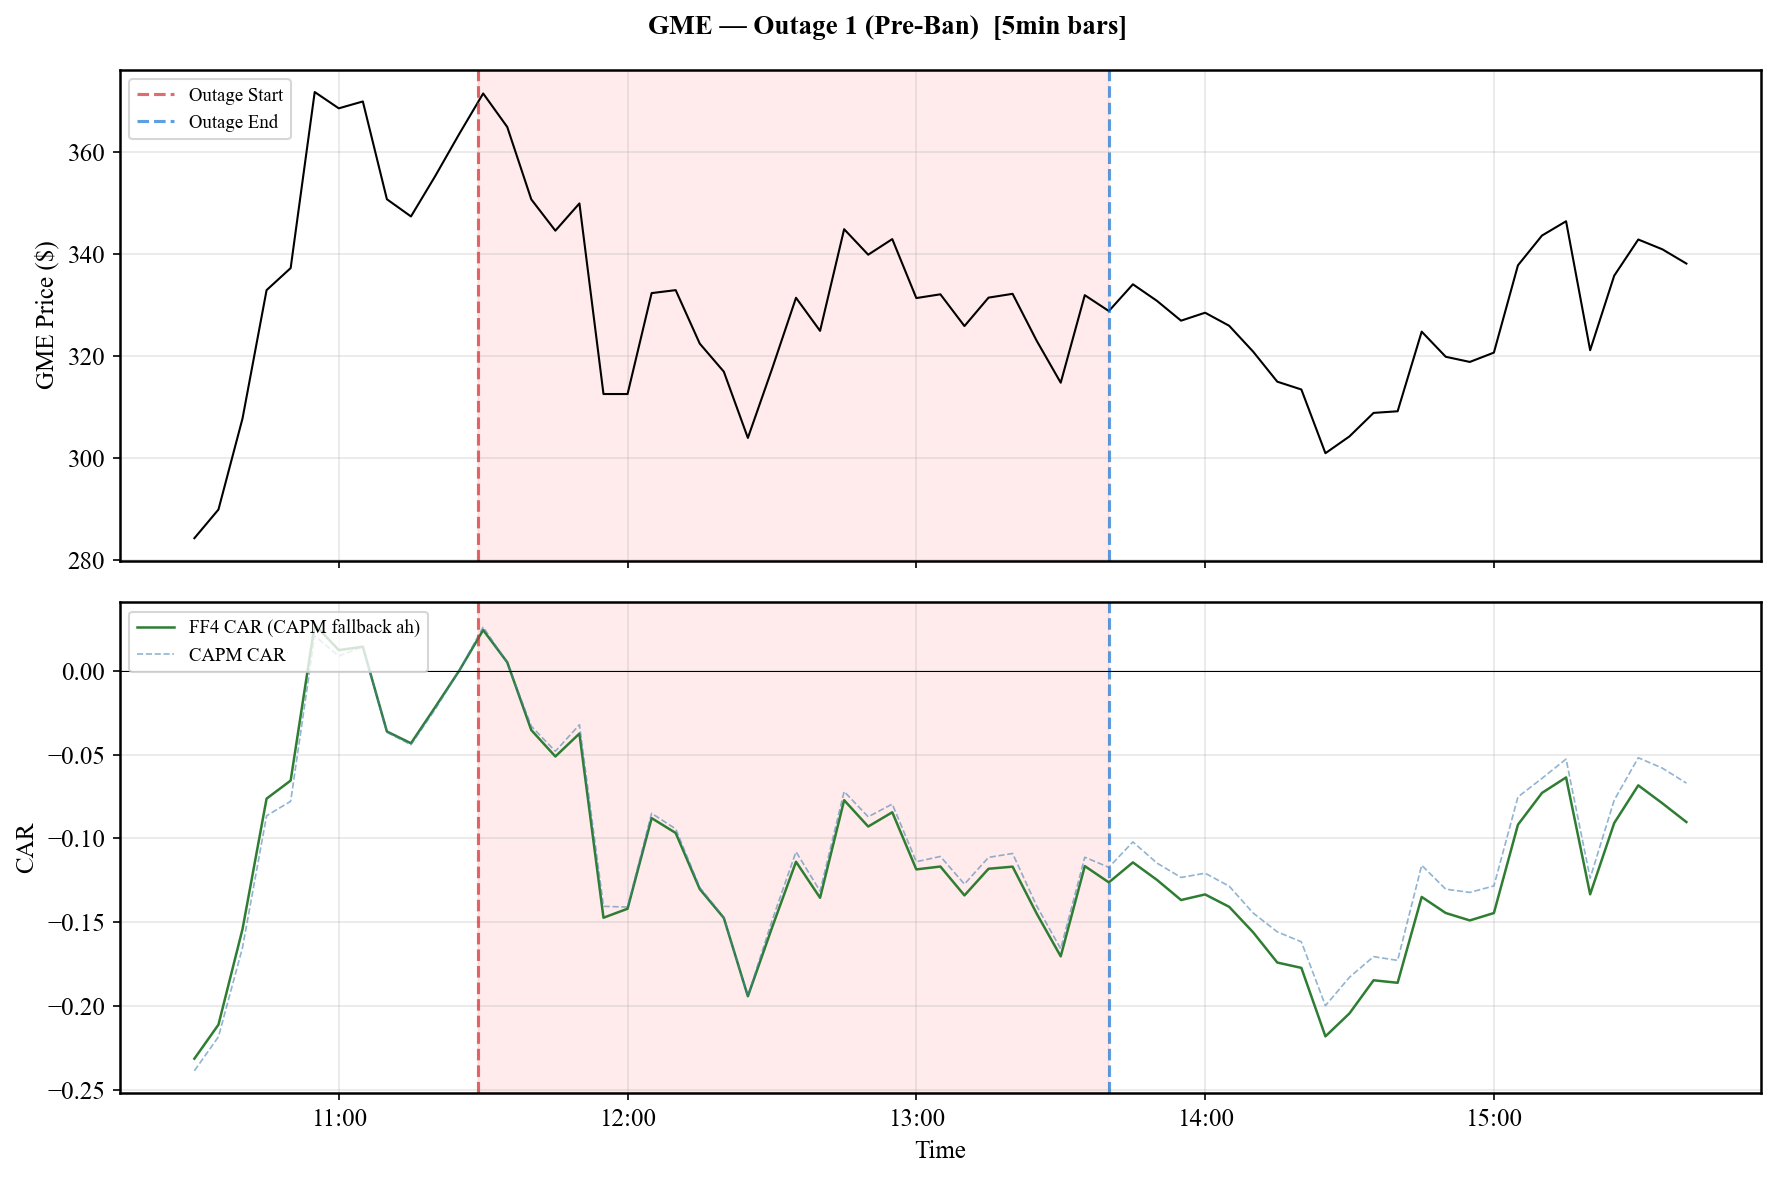

  Saved: output/multi_freq/figures/5min/gme/event_1_outage_1_pre-ban.png


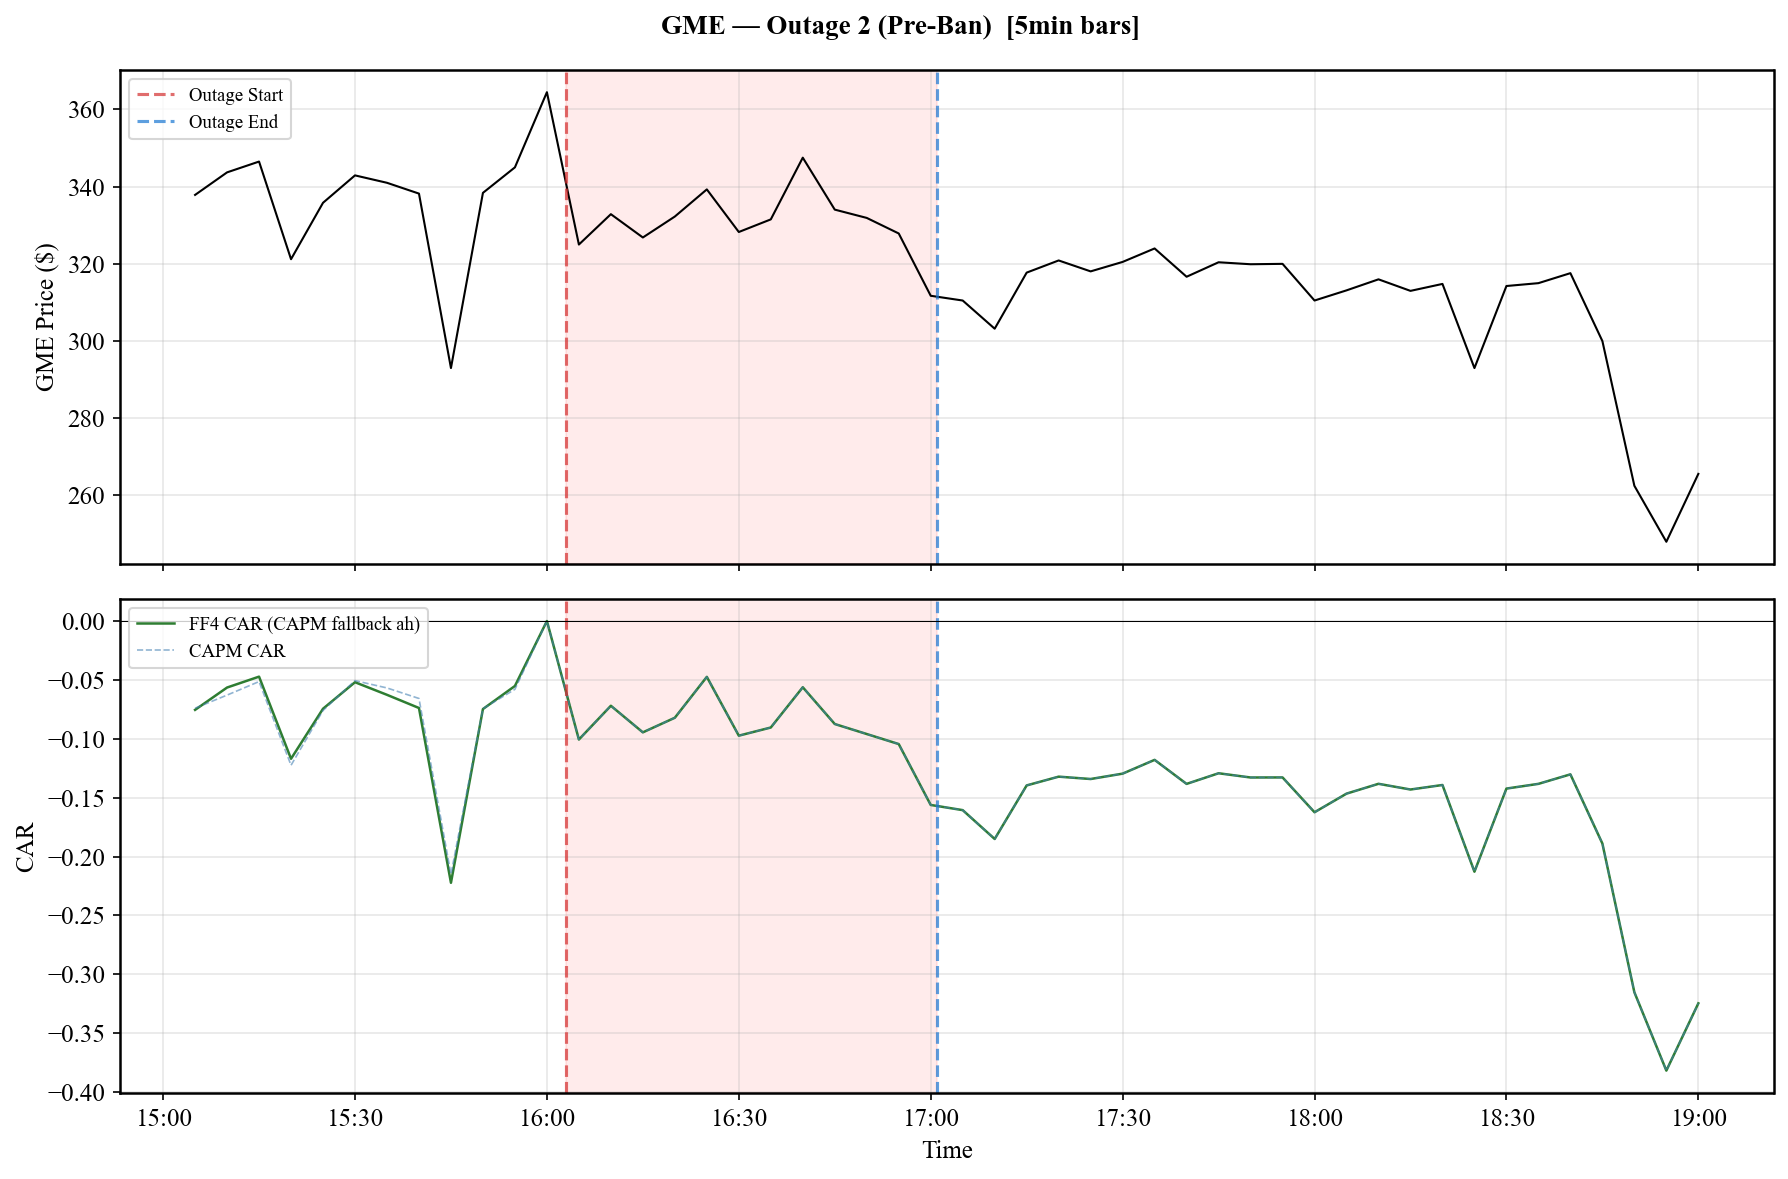

  Saved: output/multi_freq/figures/5min/gme/event_2_outage_2_pre-ban.png


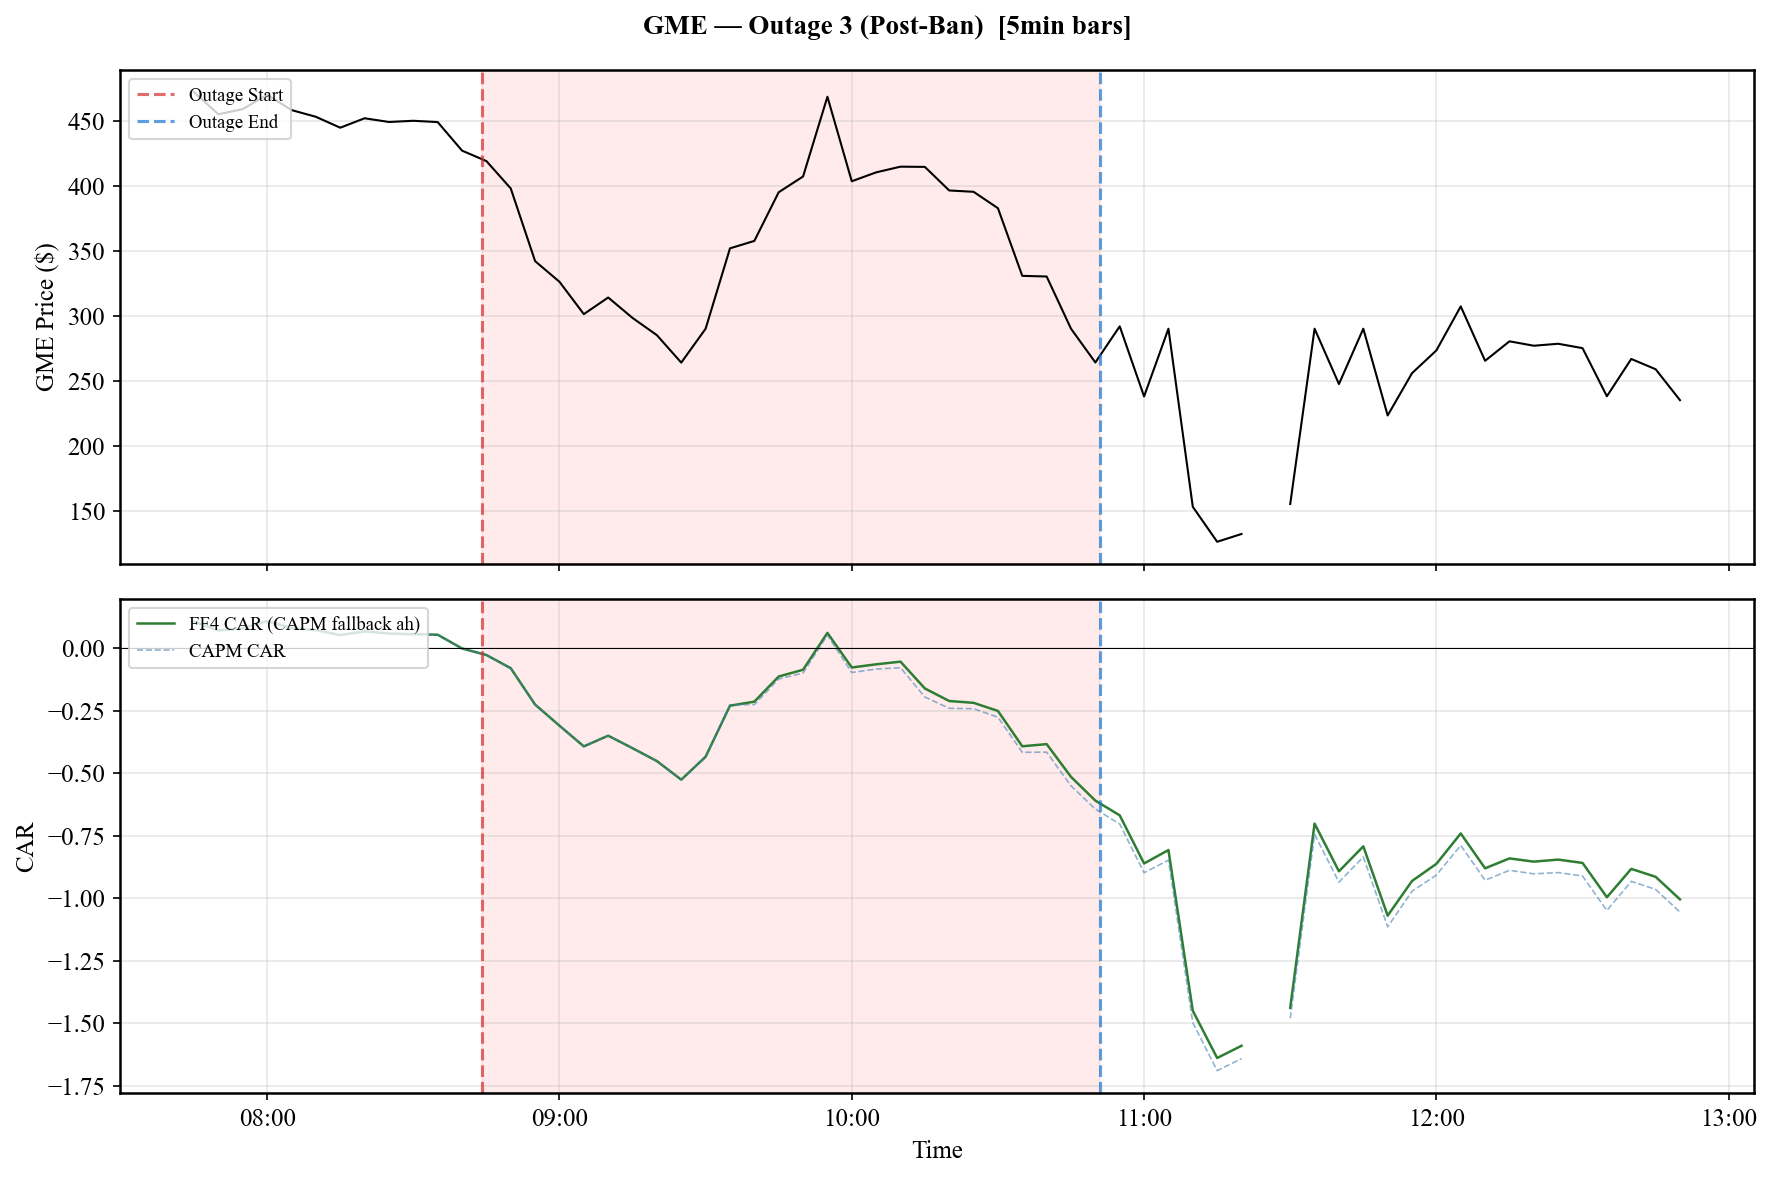

  Saved: output/multi_freq/figures/5min/gme/event_3_outage_3_post-ban.png


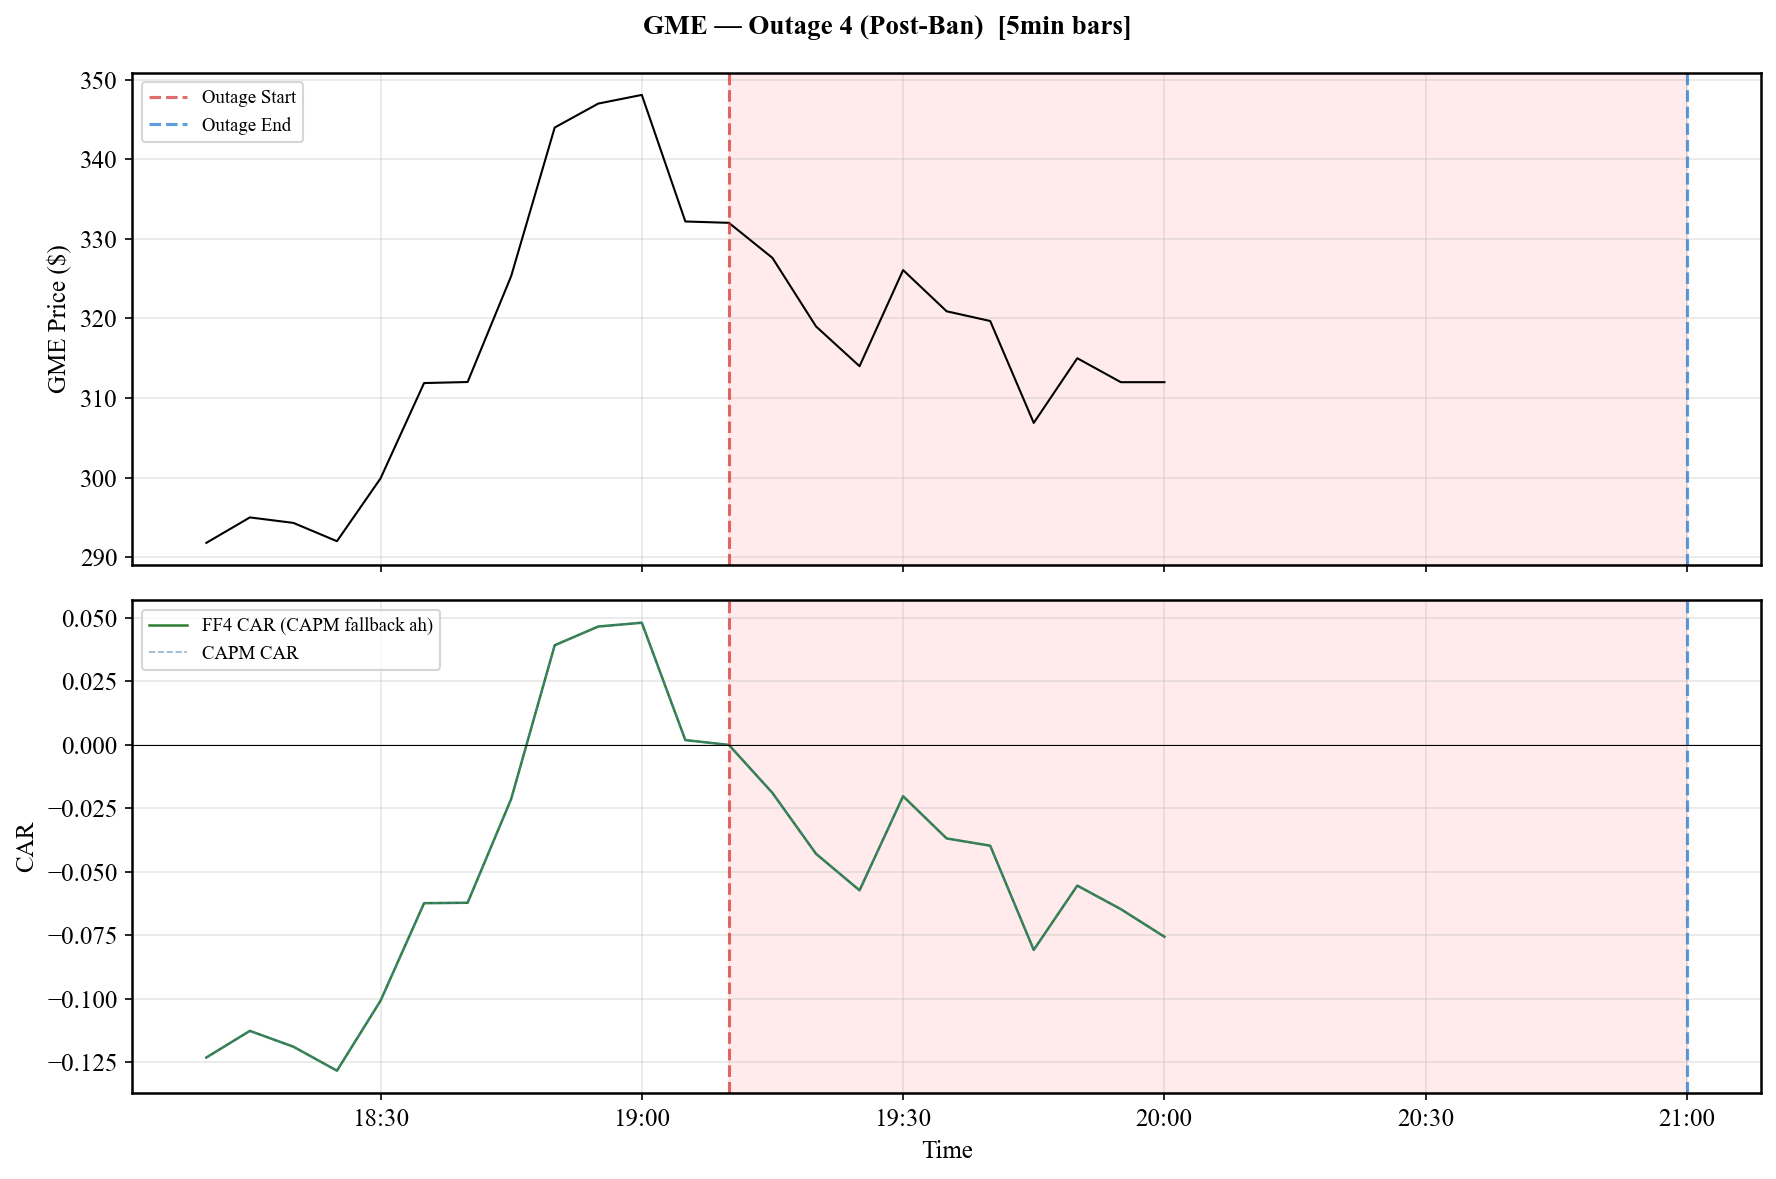

  Saved: output/multi_freq/figures/5min/gme/event_4_outage_4_post-ban.png

--- AMC @ 5min ---


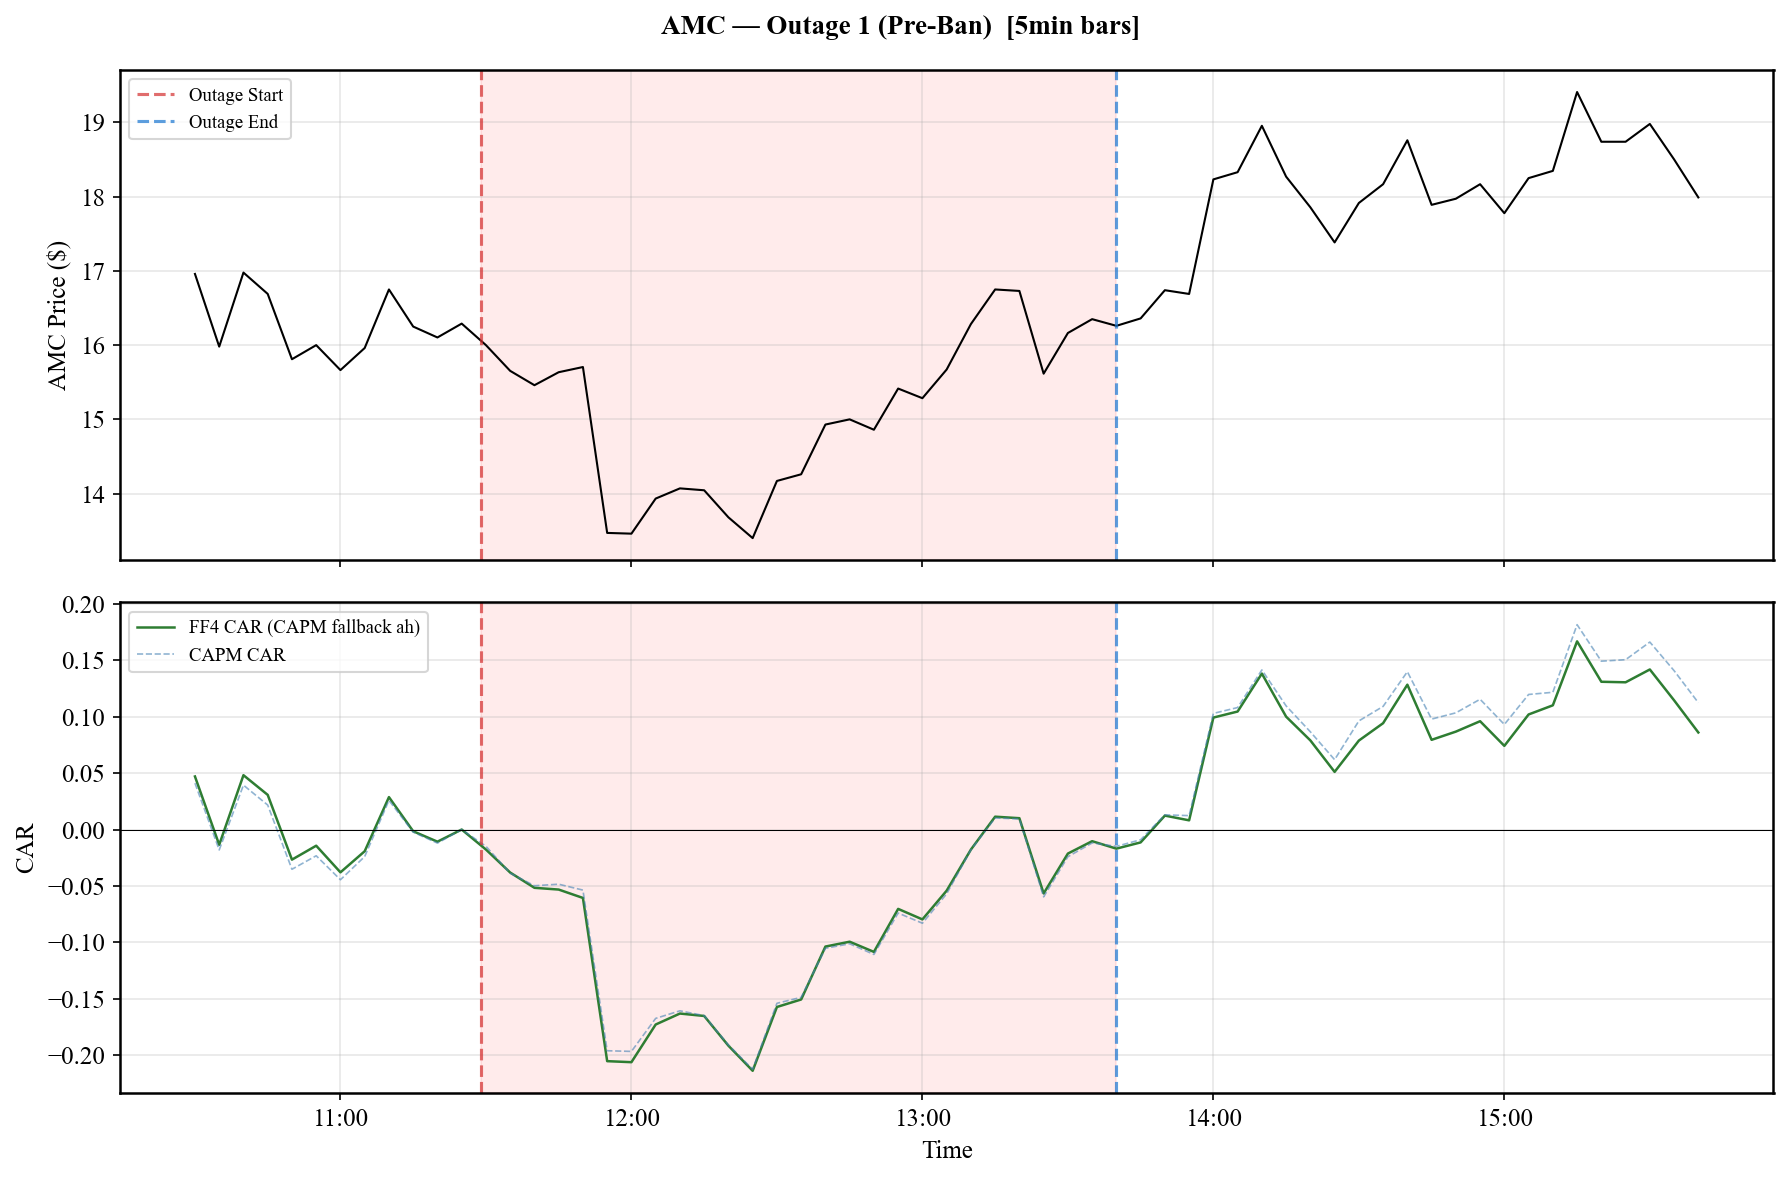

  Saved: output/multi_freq/figures/5min/amc/event_1_outage_1_pre-ban.png


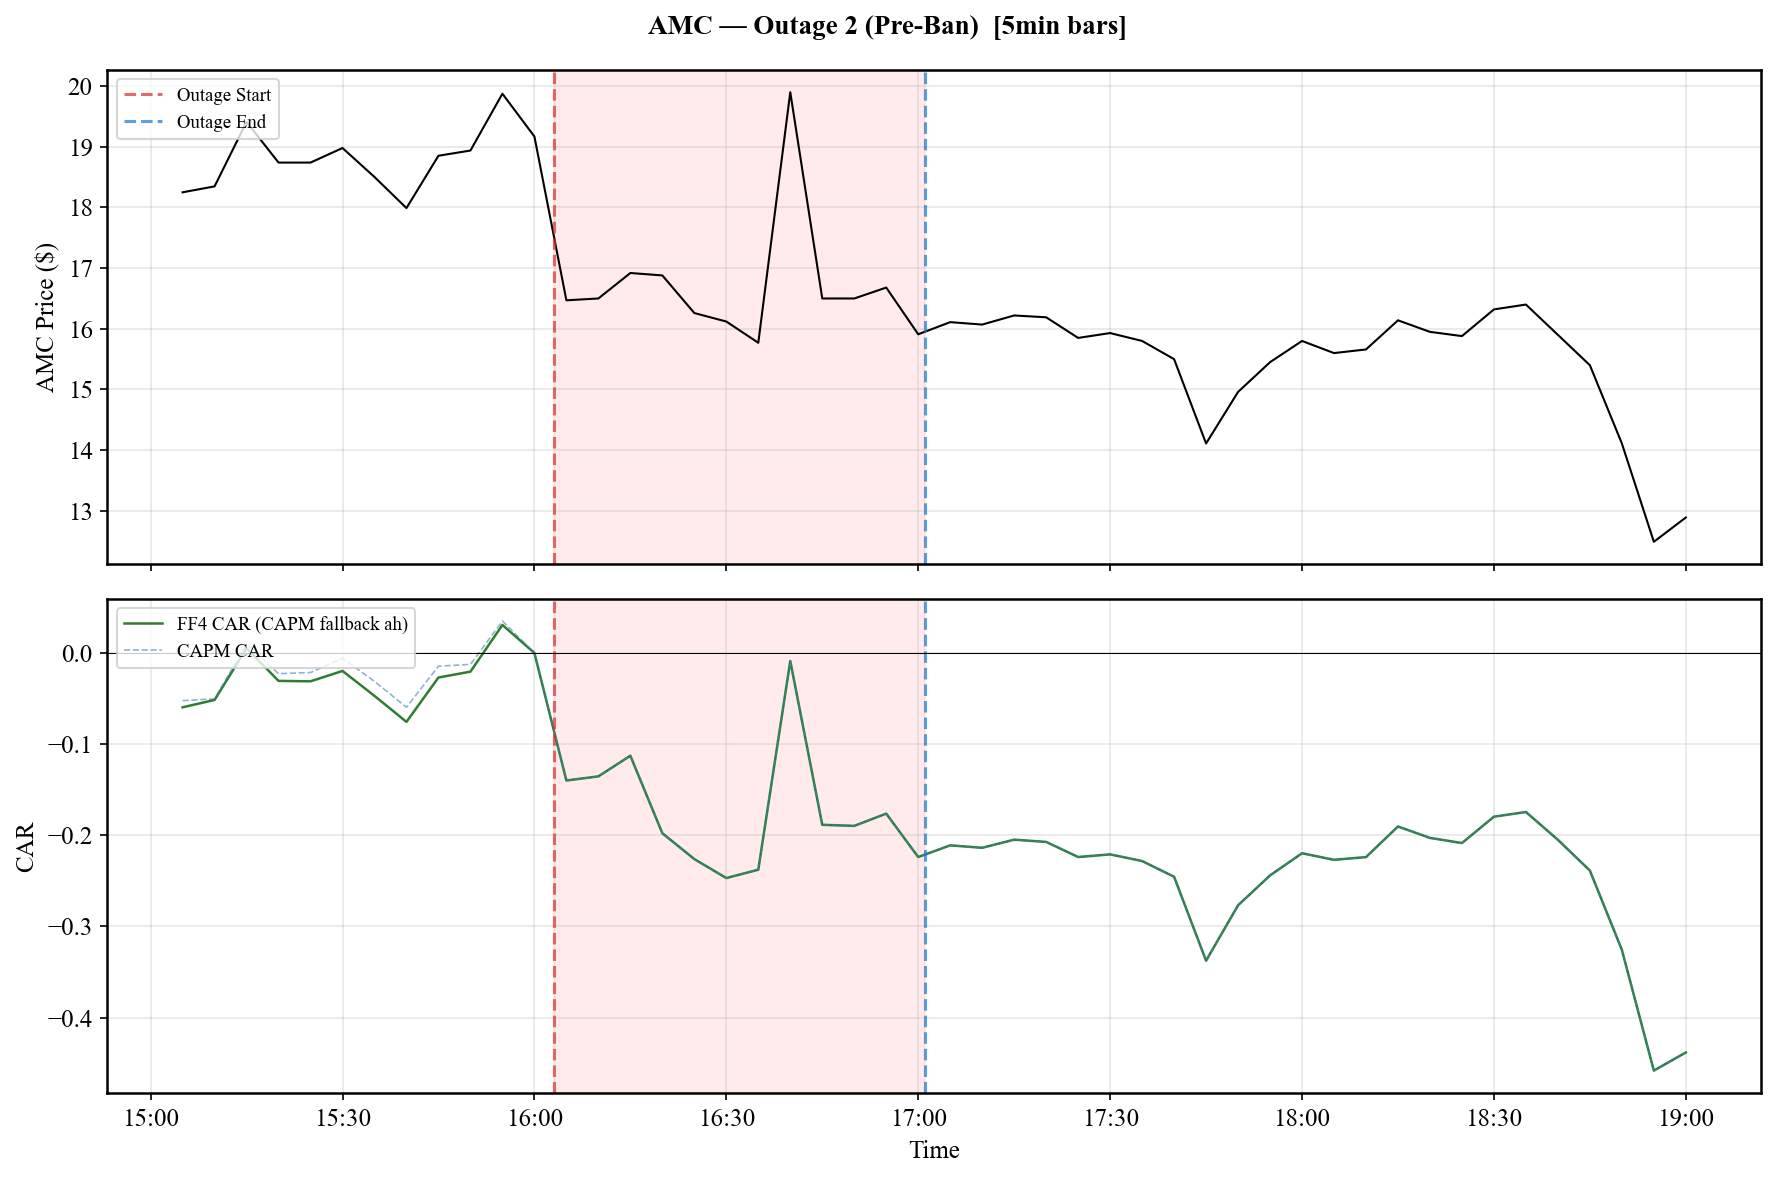

  Saved: output/multi_freq/figures/5min/amc/event_2_outage_2_pre-ban.png


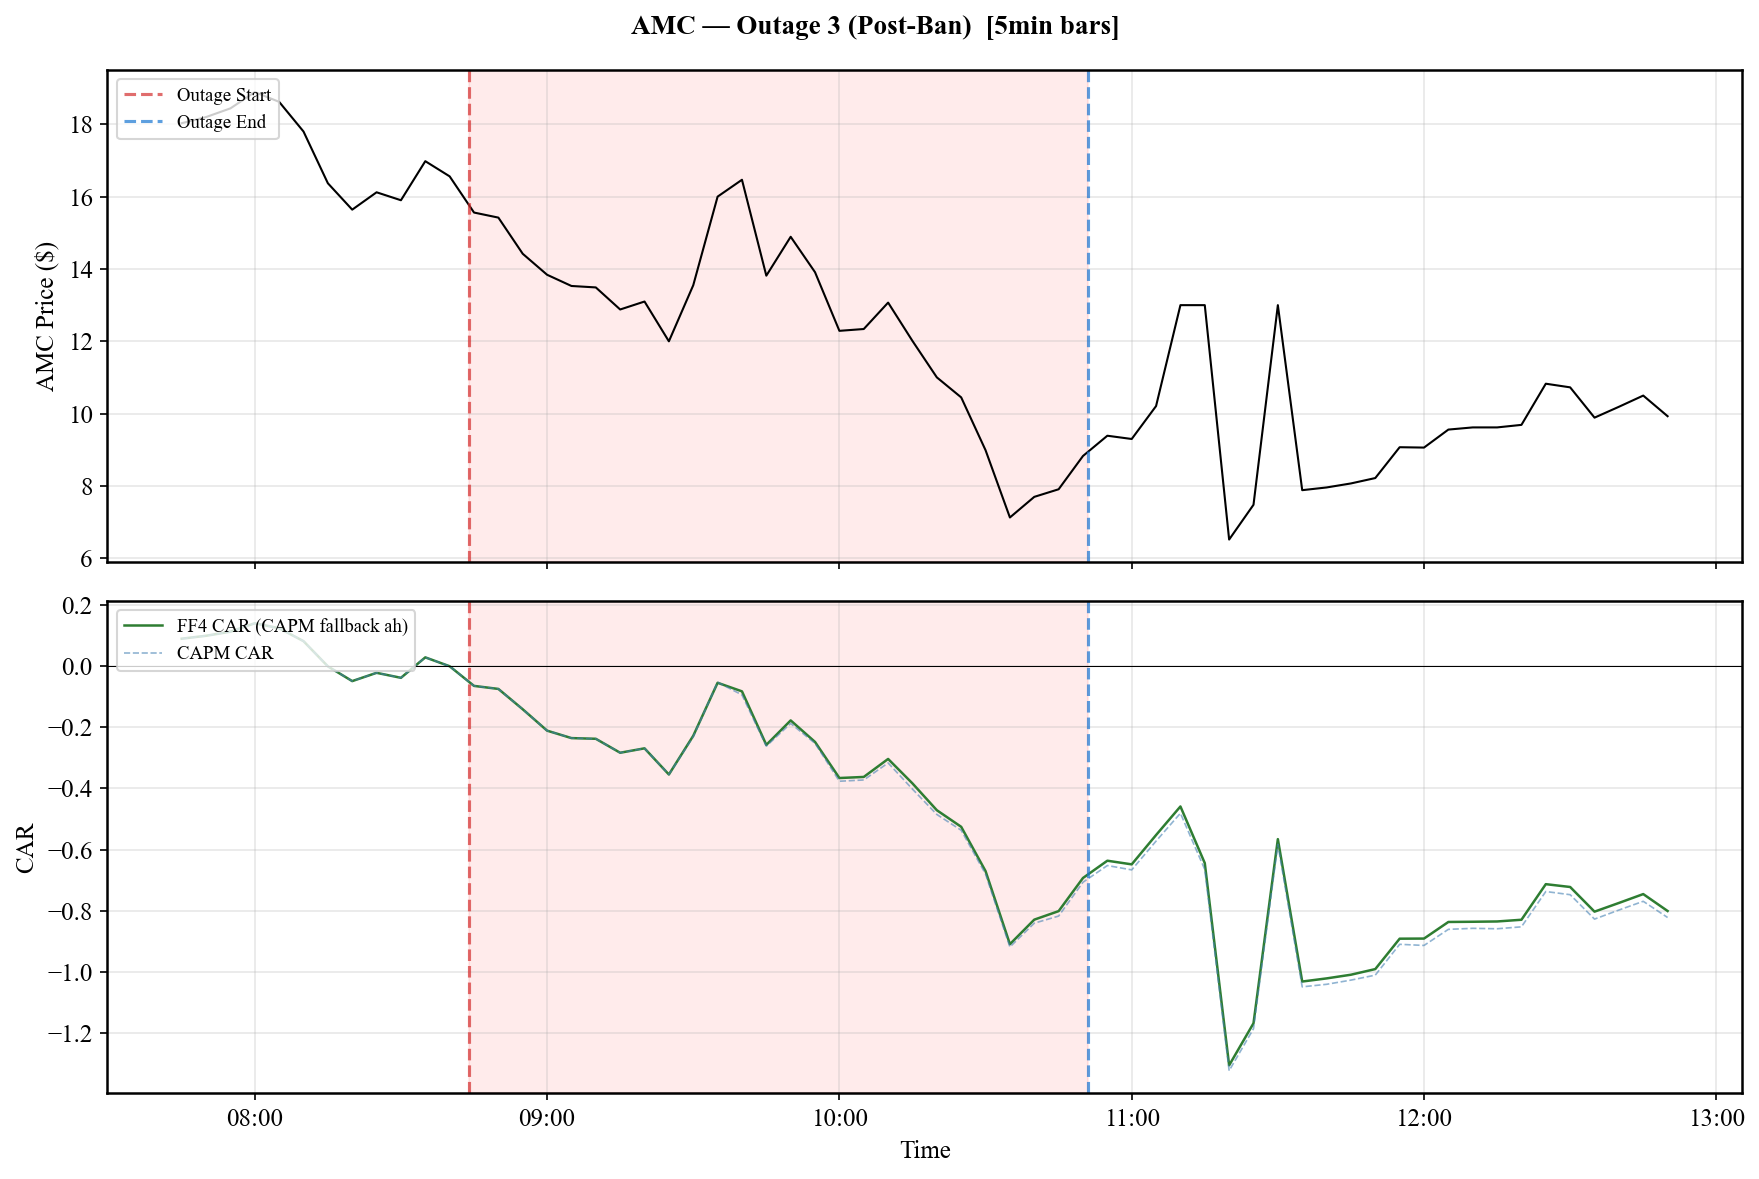

  Saved: output/multi_freq/figures/5min/amc/event_3_outage_3_post-ban.png


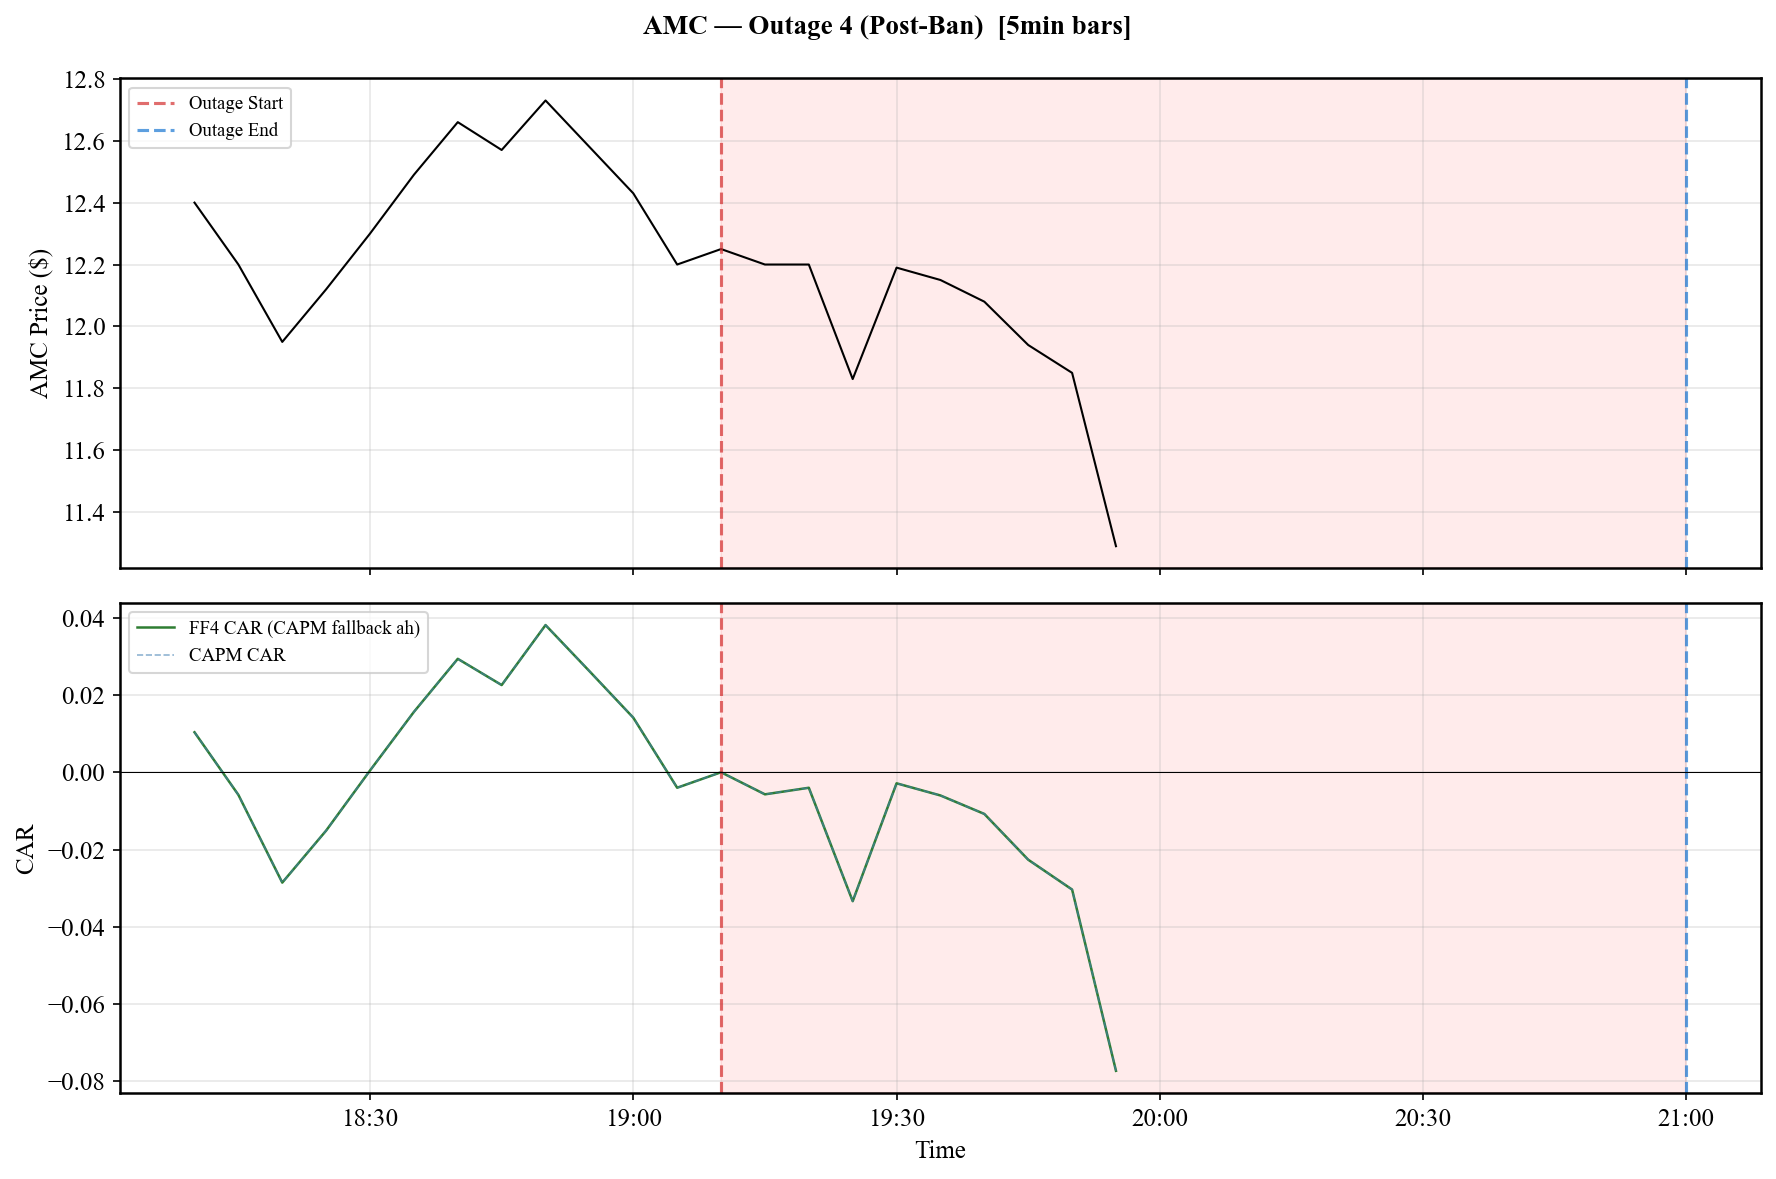

  Saved: output/multi_freq/figures/5min/amc/event_4_outage_4_post-ban.png

======================================================= 10min =======================================================

--- GME @ 10min ---


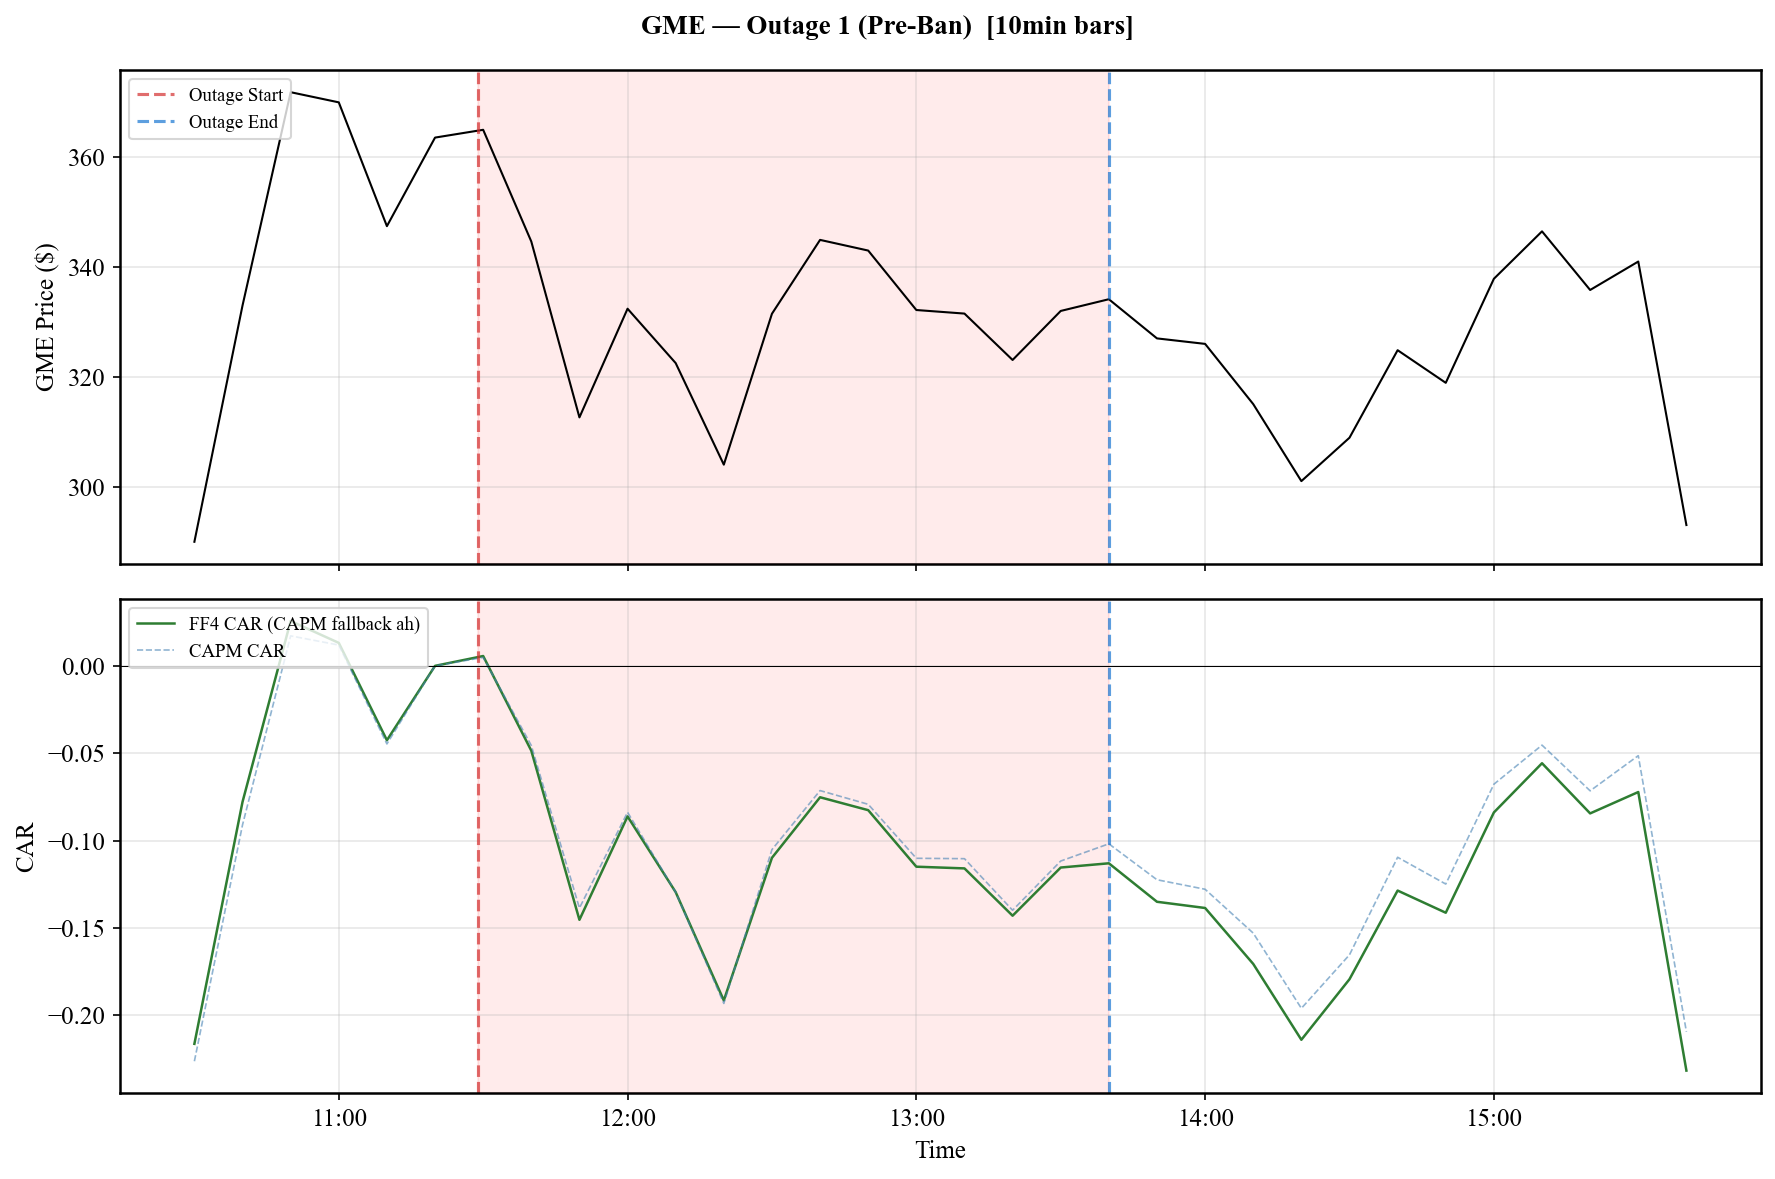

  Saved: output/multi_freq/figures/10min/gme/event_1_outage_1_pre-ban.png


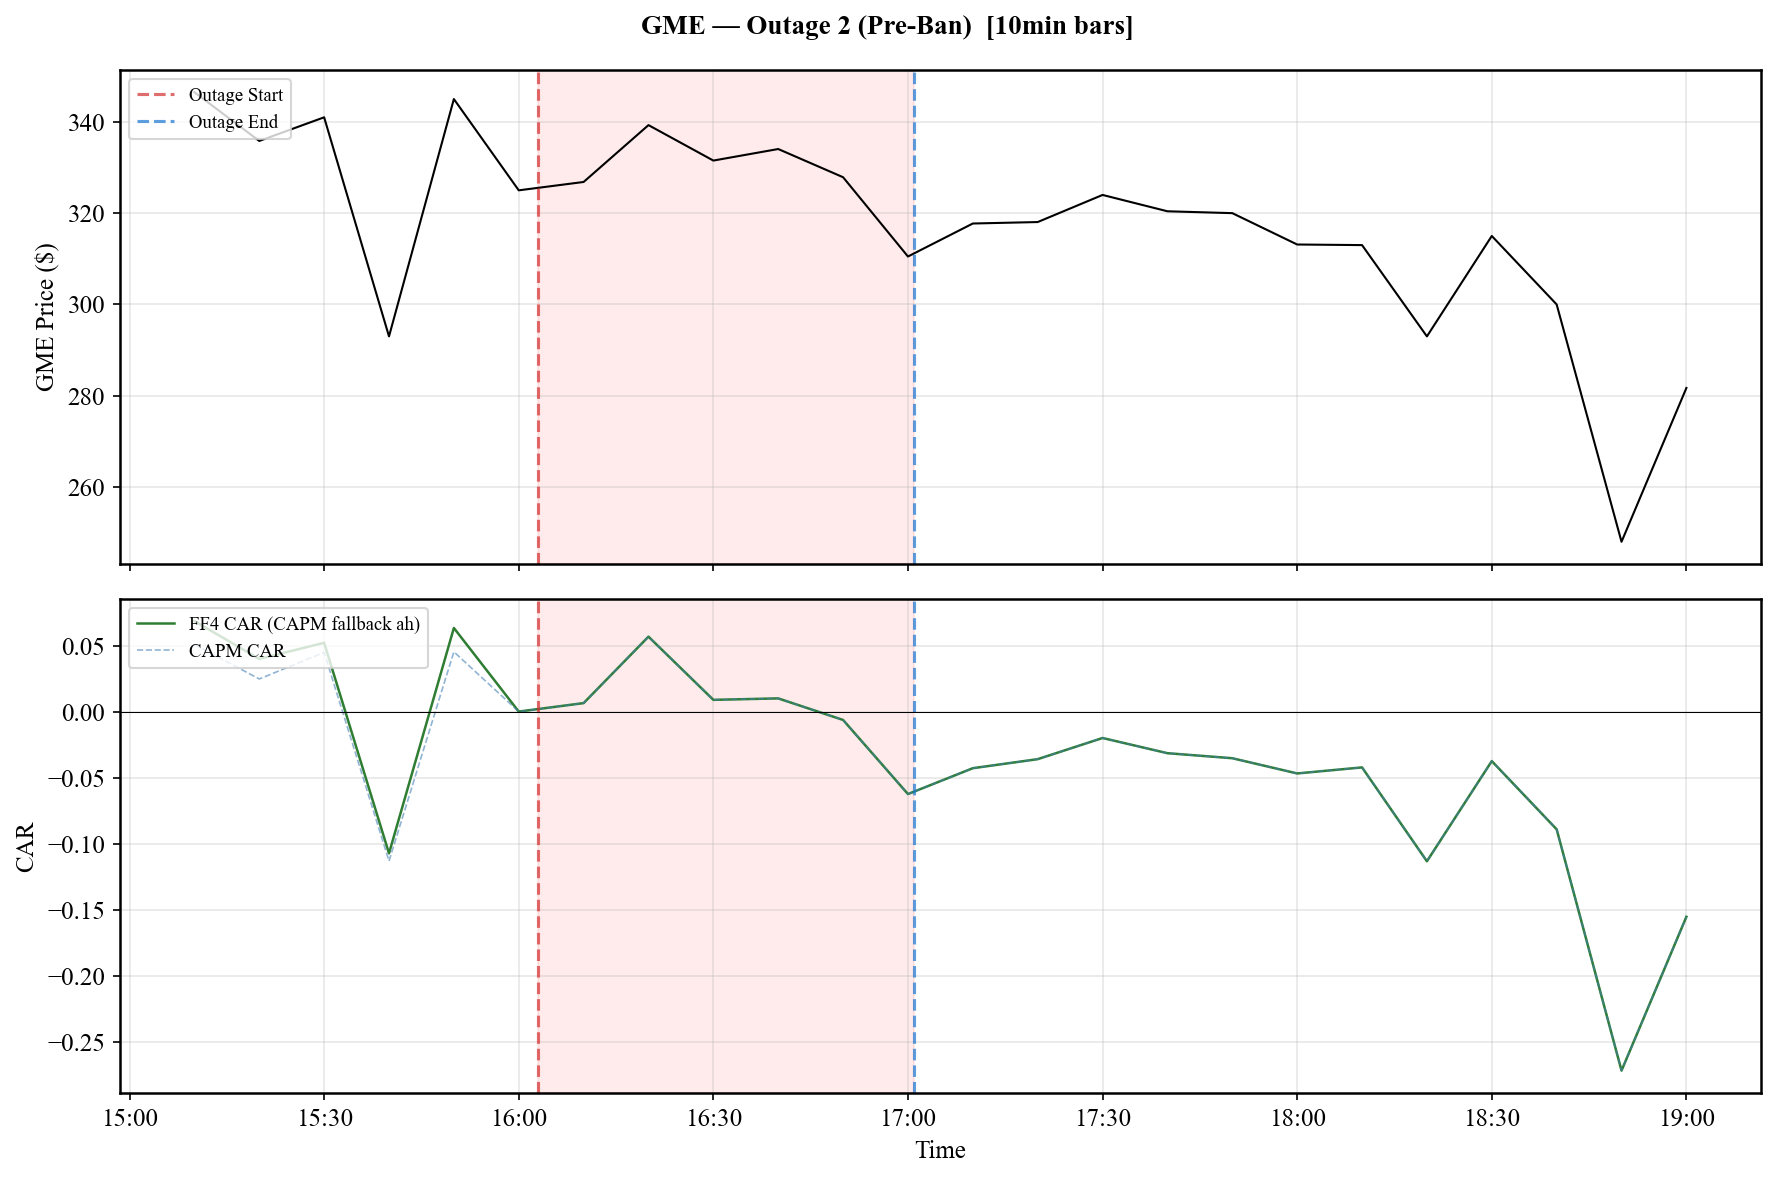

  Saved: output/multi_freq/figures/10min/gme/event_2_outage_2_pre-ban.png


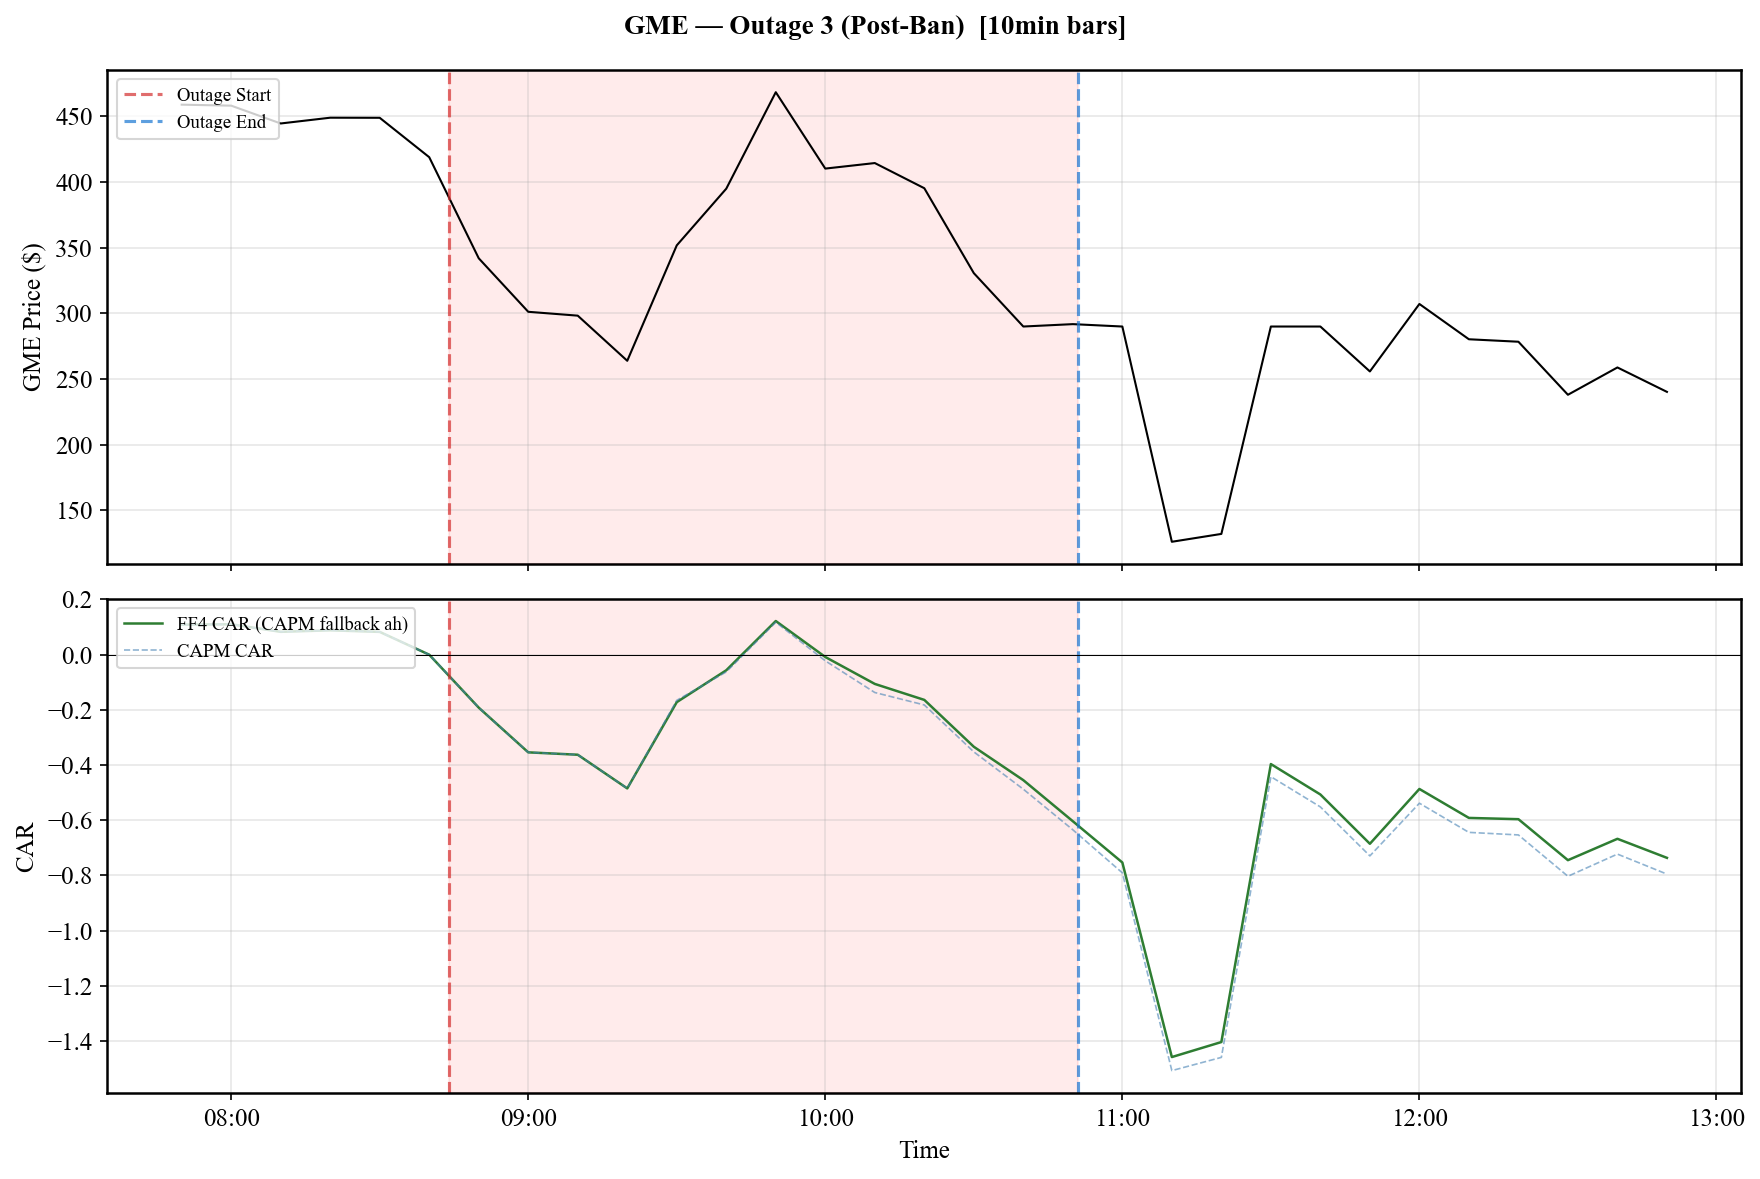

  Saved: output/multi_freq/figures/10min/gme/event_3_outage_3_post-ban.png


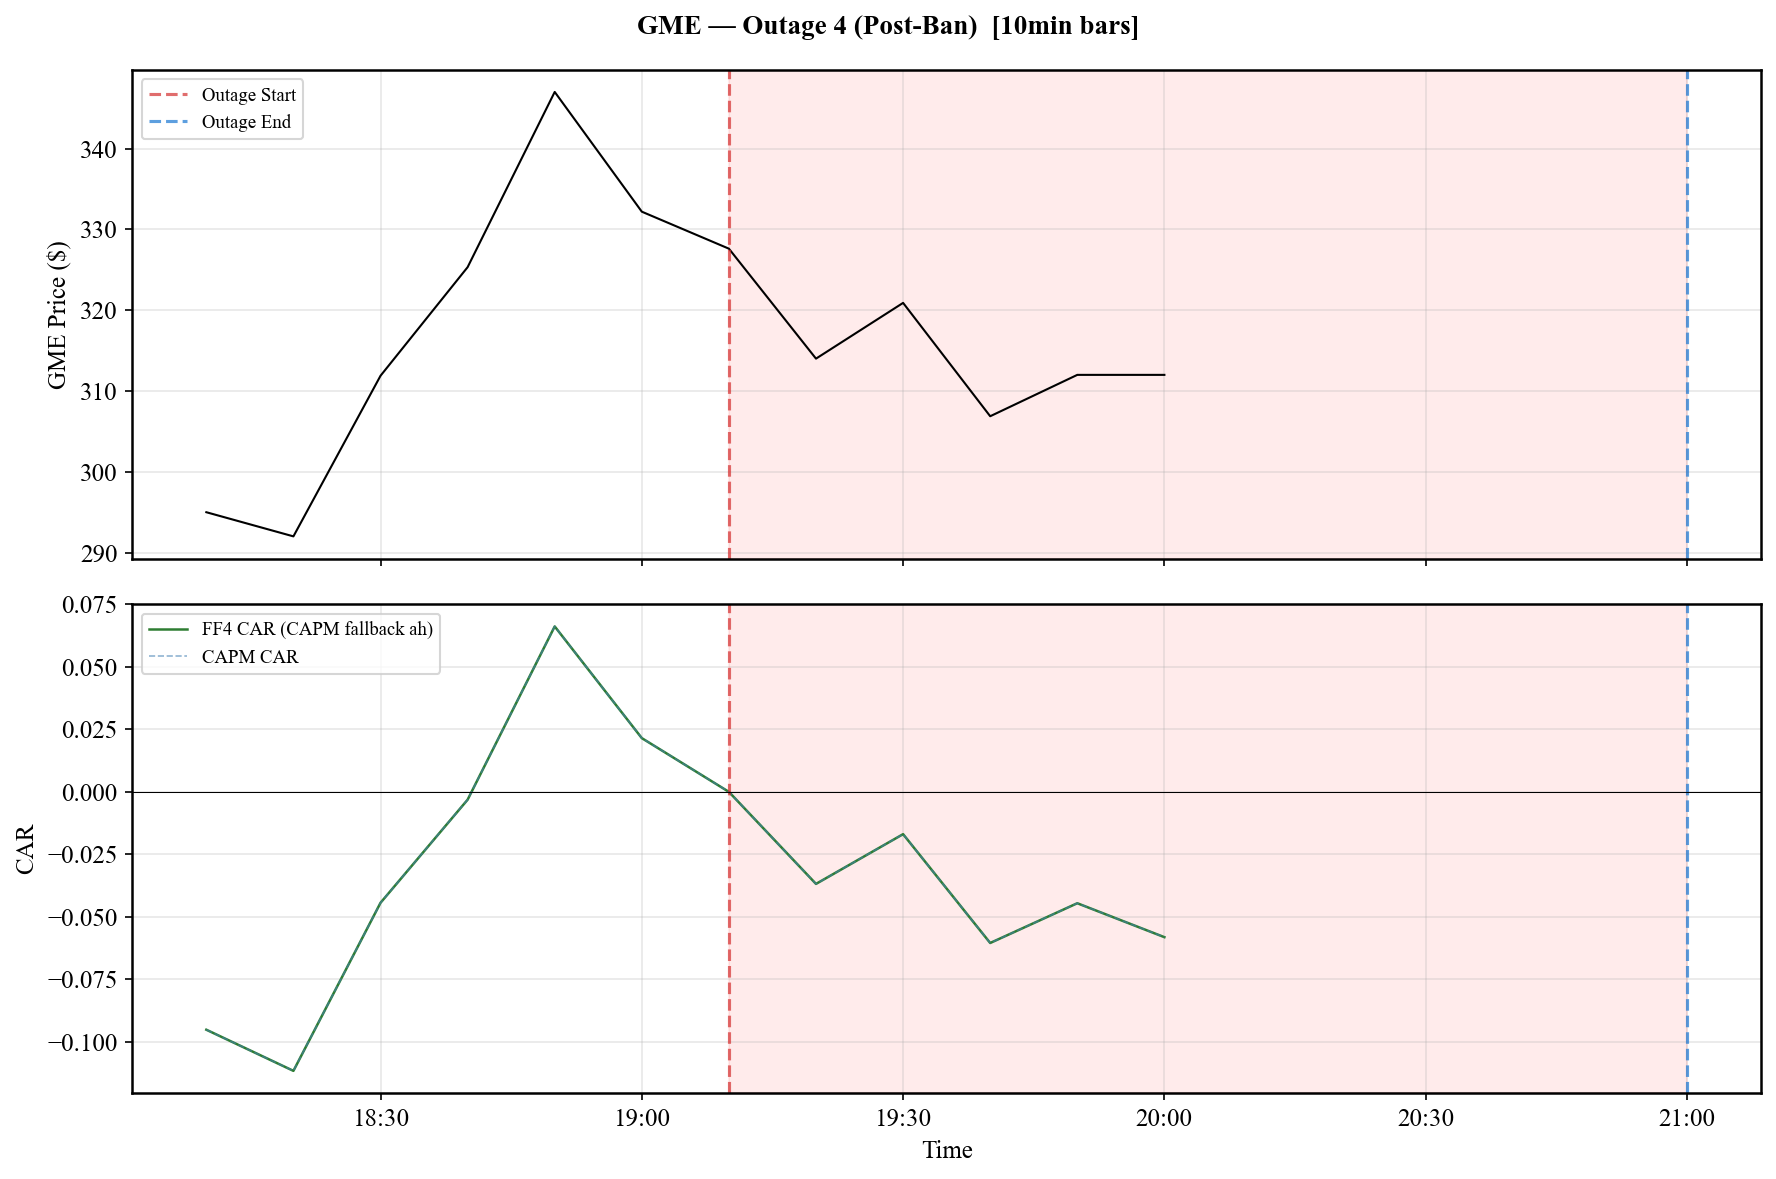

  Saved: output/multi_freq/figures/10min/gme/event_4_outage_4_post-ban.png

--- AMC @ 10min ---


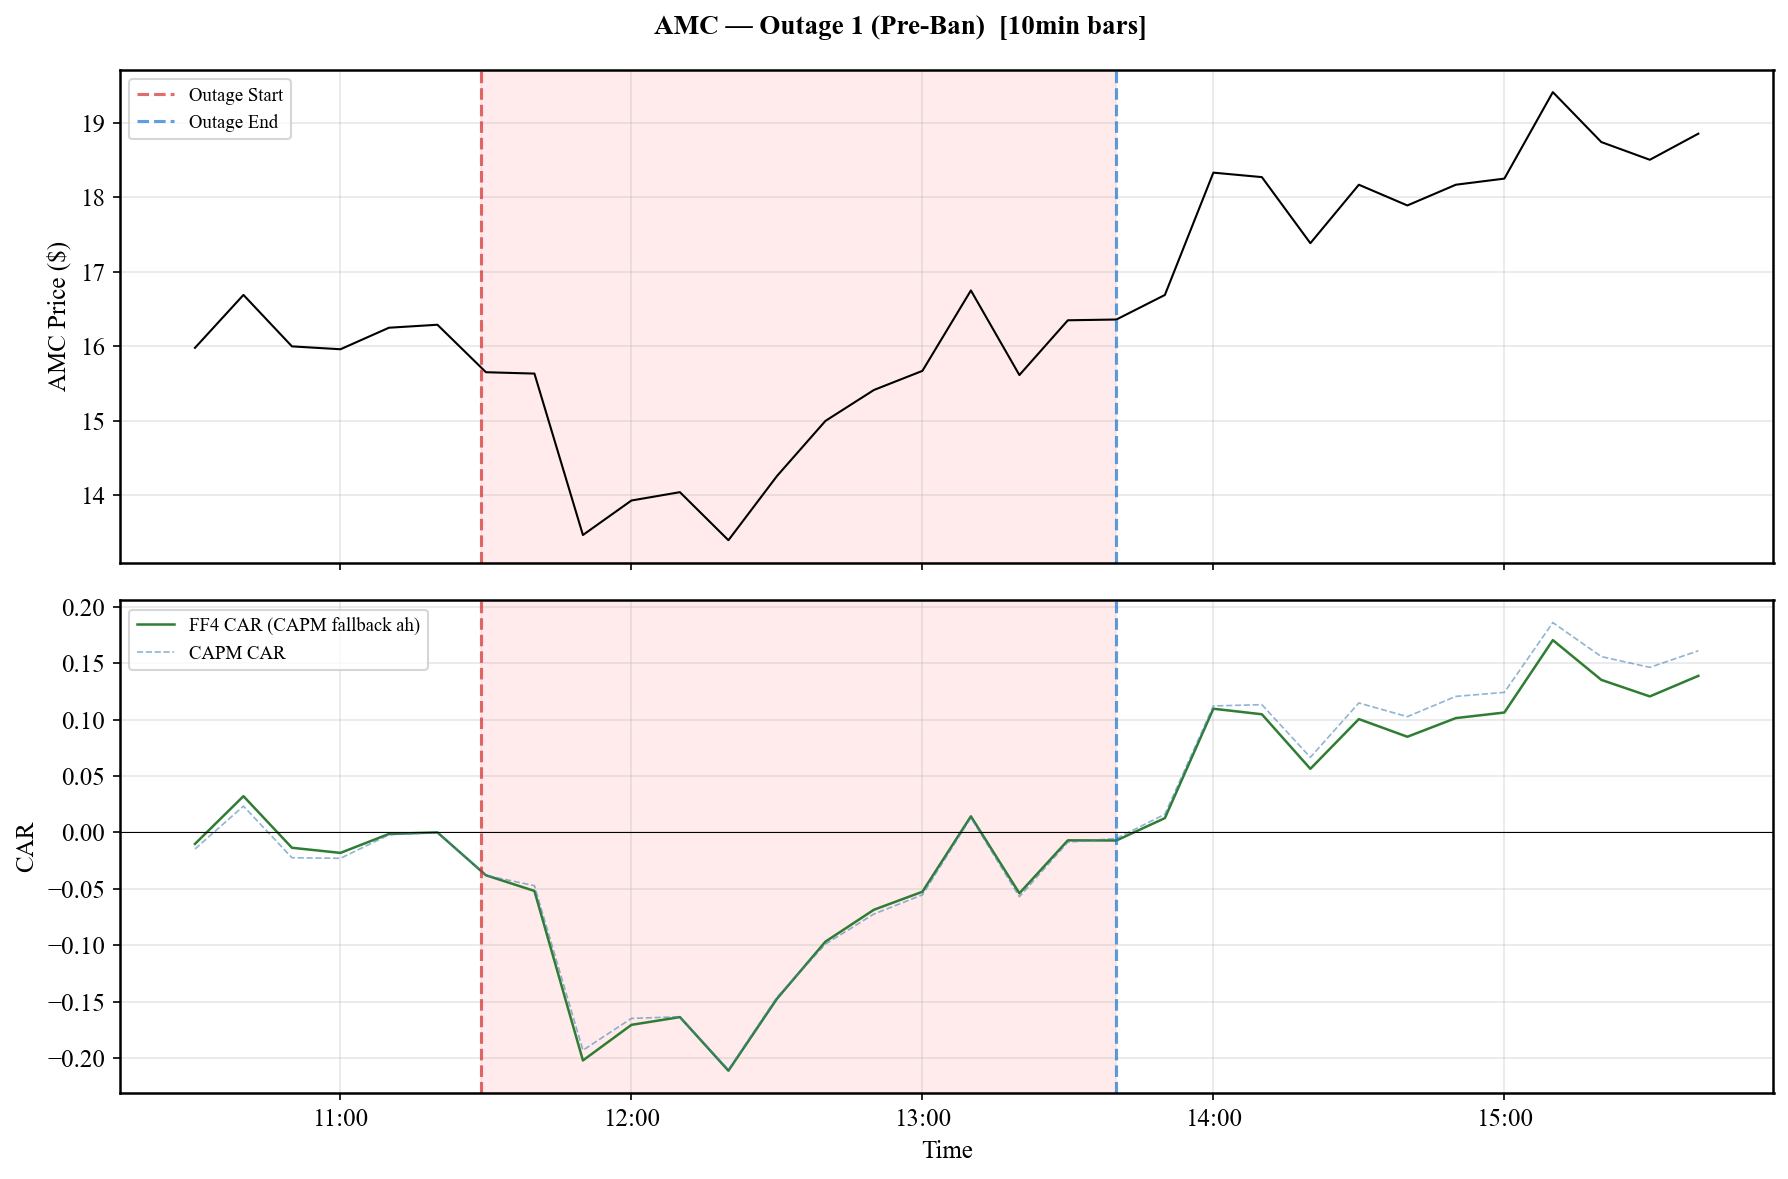

  Saved: output/multi_freq/figures/10min/amc/event_1_outage_1_pre-ban.png


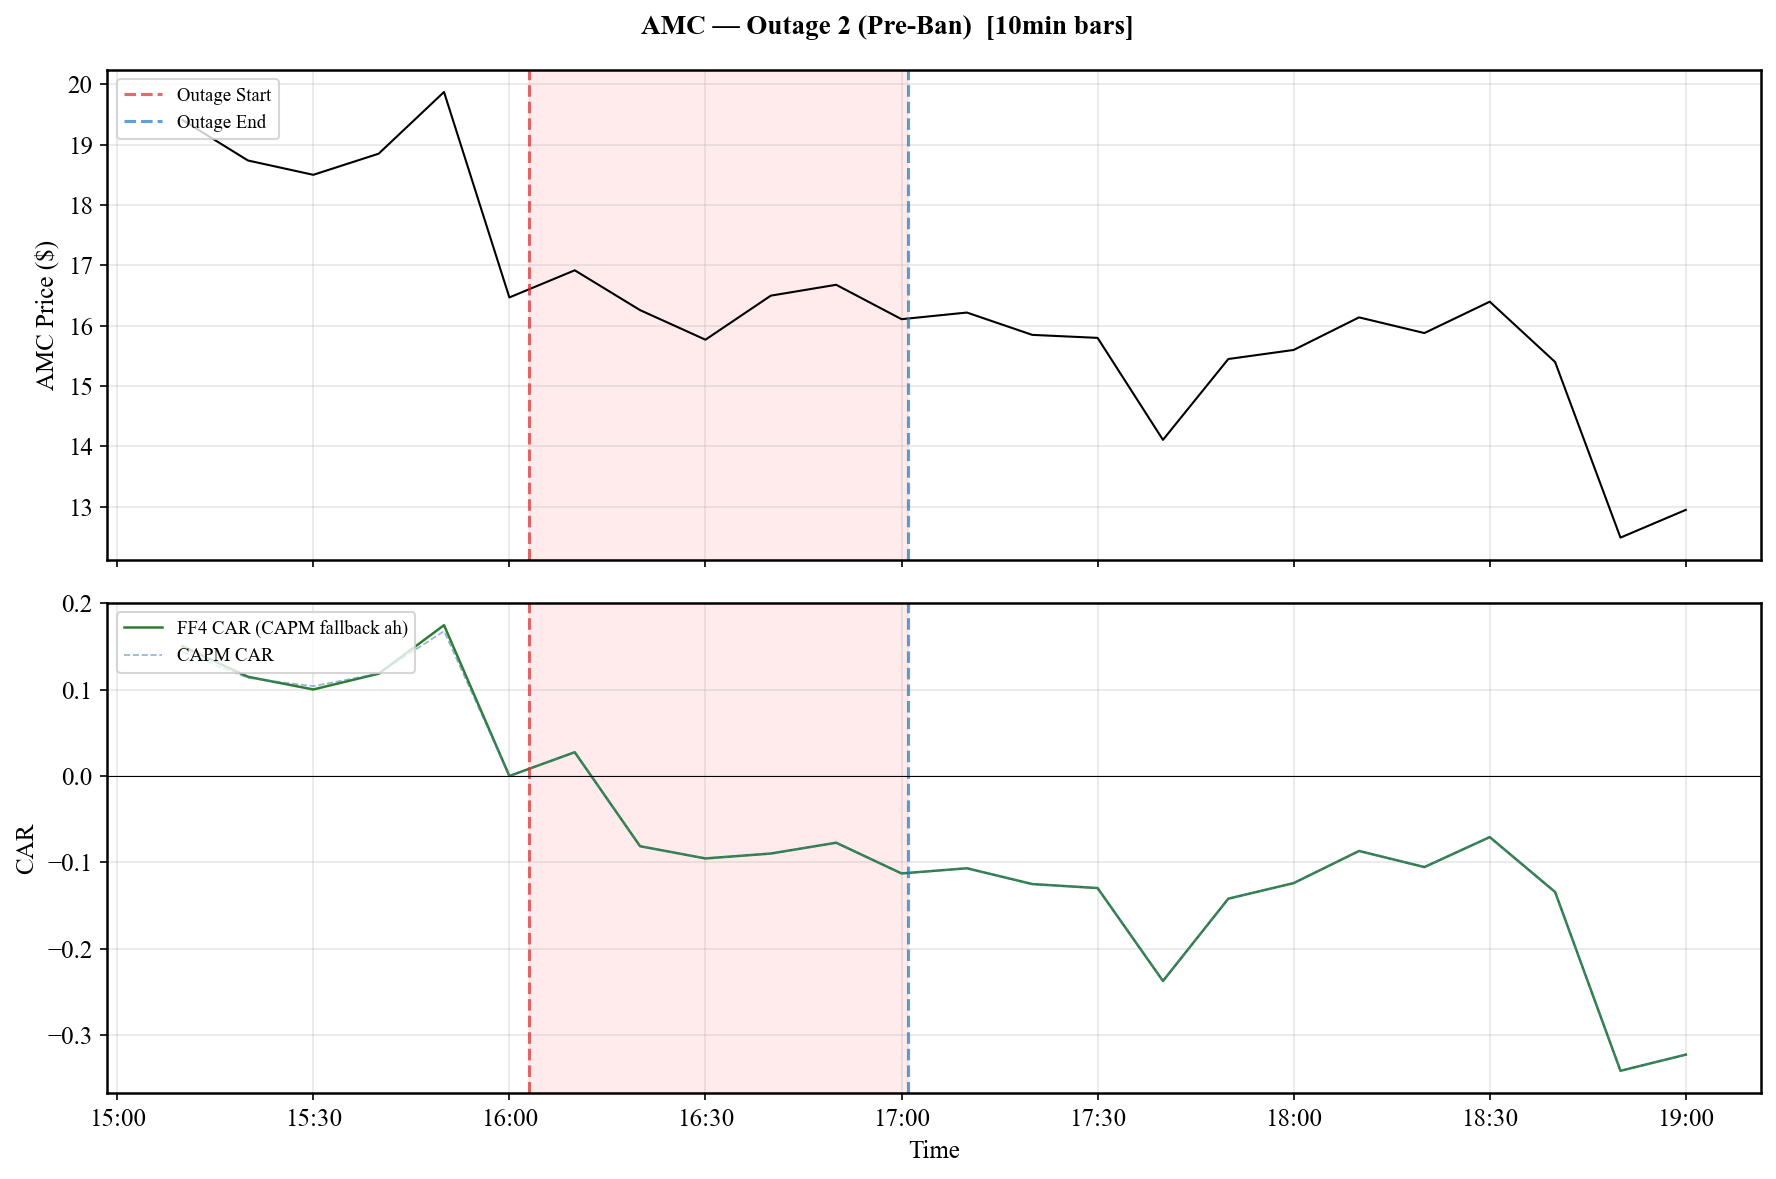

  Saved: output/multi_freq/figures/10min/amc/event_2_outage_2_pre-ban.png


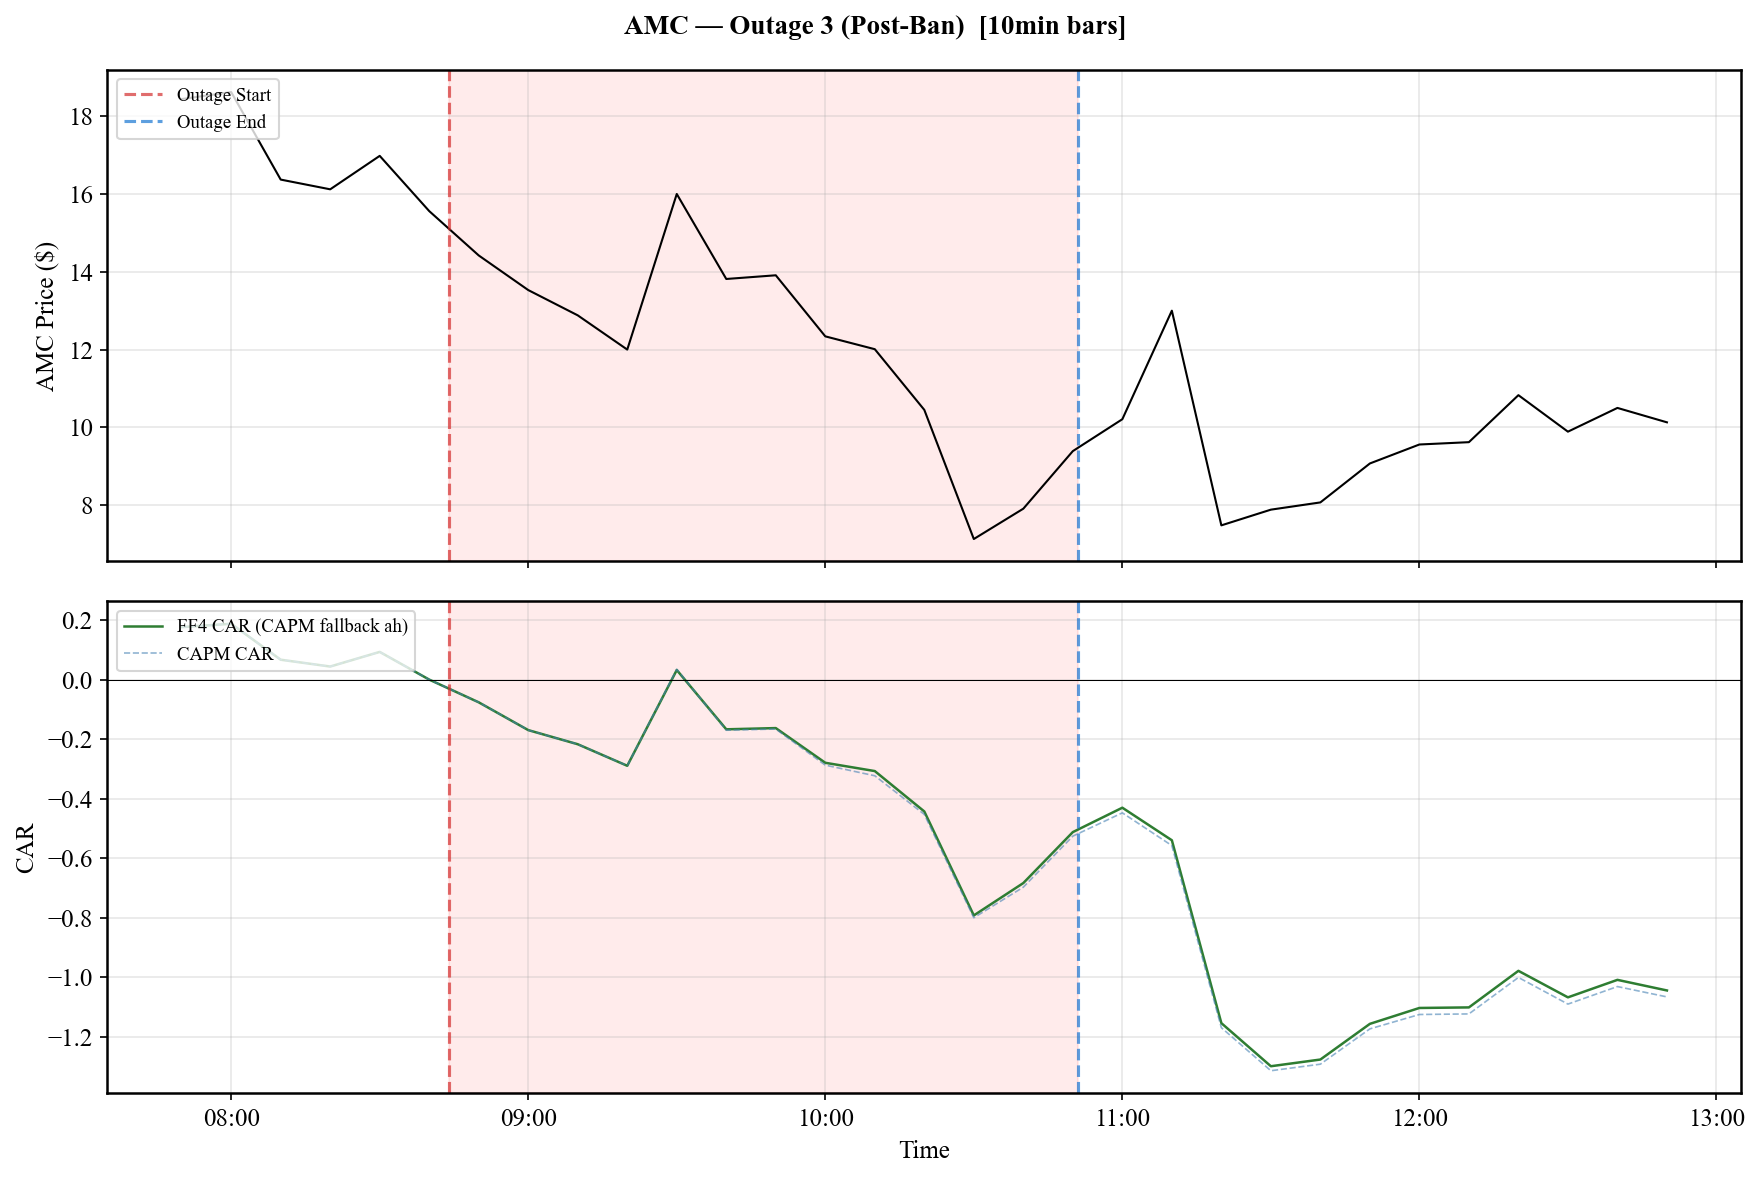

  Saved: output/multi_freq/figures/10min/amc/event_3_outage_3_post-ban.png


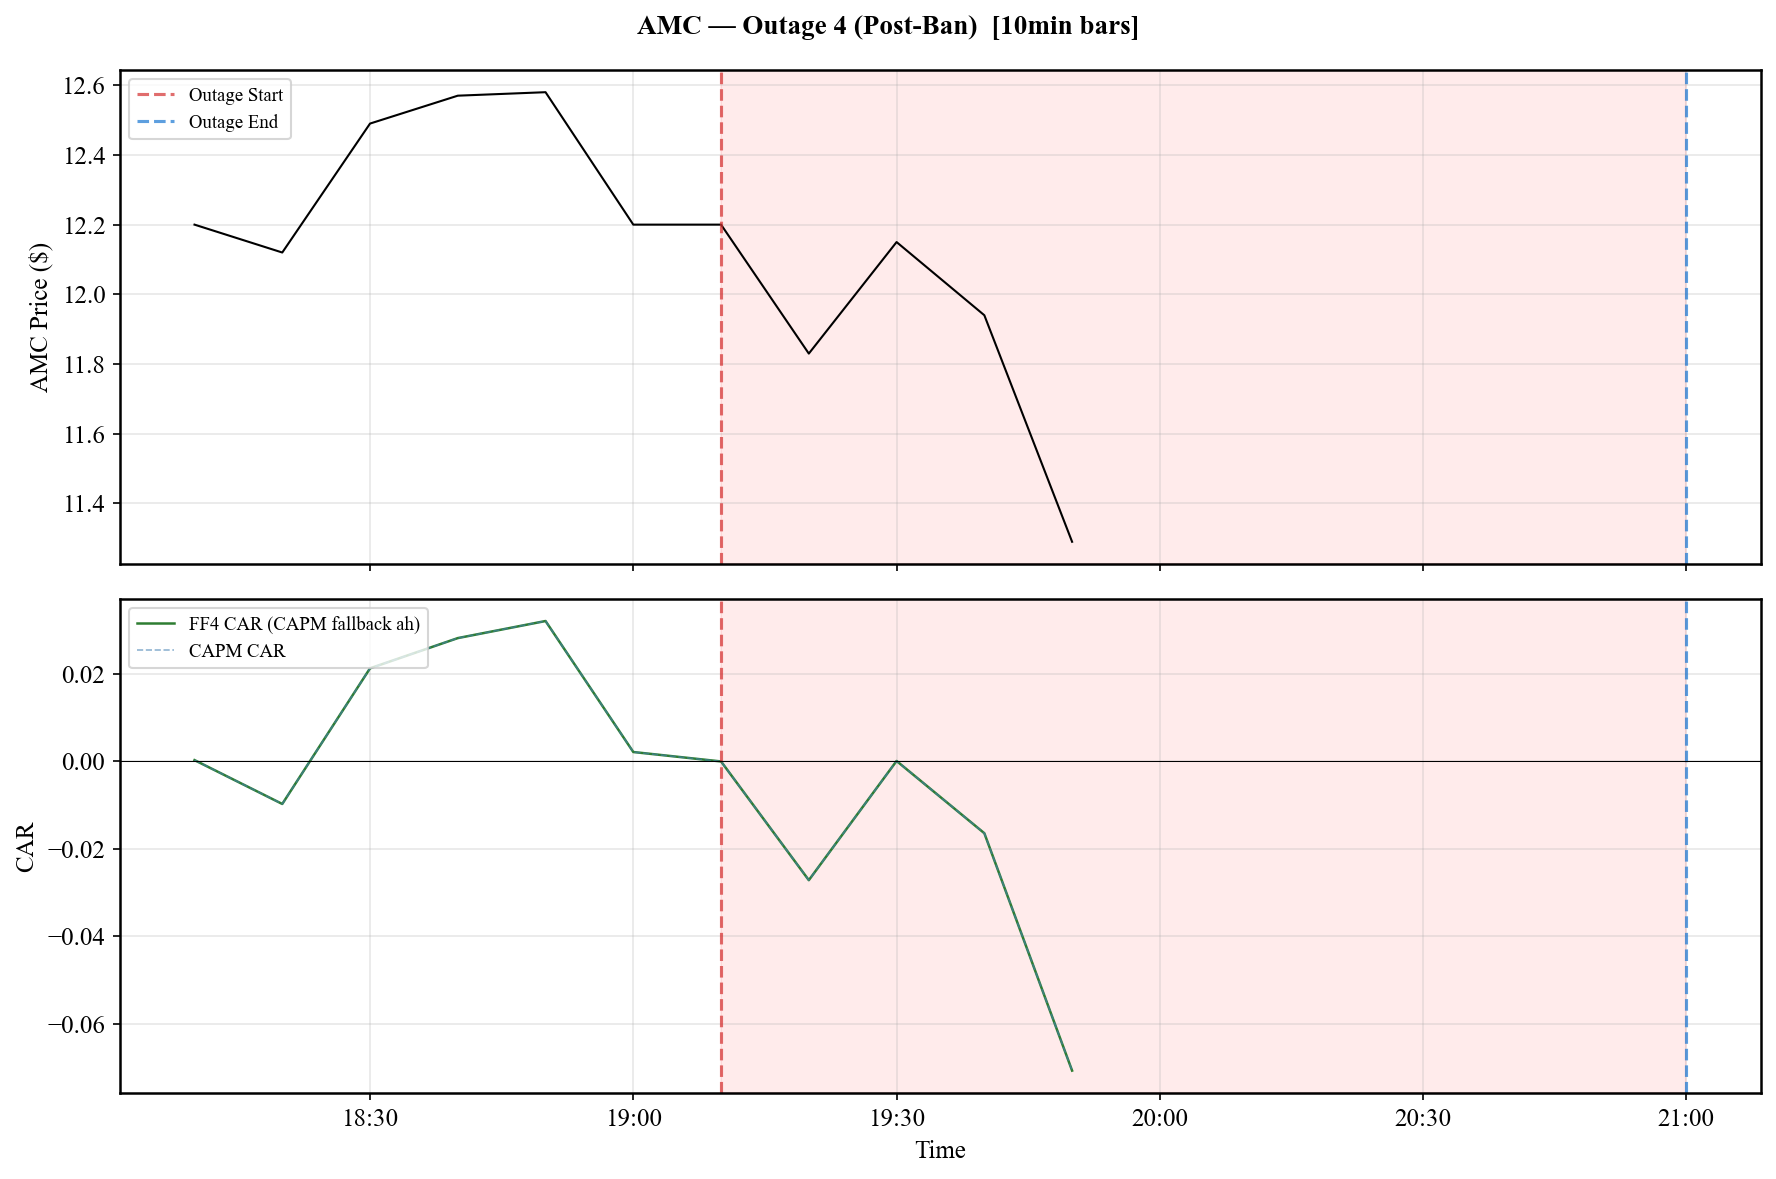

  Saved: output/multi_freq/figures/10min/amc/event_4_outage_4_post-ban.png


In [5]:
def plot_event_detail(result, symbol, freq_name, event_num):
    """Two-panel figure: stock price + FF4 CAR path for a single outage event.
    Includes a 1-hour pre-period to the left of the outage window so that
    pre-trends are visible. CARs are normalized to 0 at outage start."""
    ed = result["event_data"]
    if ed.empty:
        return

    event_start = result["start_time"]
    event_end   = result["end_time"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(
        f"{symbol} — {result['event_name']}  [{freq_name} bars]",
        fontsize=13, fontweight="bold"
    )

    # ── Top: price ─────────────────────────────────────────────────────────────
    ax1.plot(ed.index, ed["price"], color="black", linewidth=1.0)
    ax1.axvline(event_start, color=PRE_BAN_COLOR,  linestyle="--", alpha=0.7, label="Outage Start")
    ax1.axvline(event_end,   color=POST_BAN_COLOR, linestyle="--", alpha=0.7, label="Outage End")
    ax1.axvspan(event_start, event_end, alpha=0.08, color="red")
    ax1.set_ylabel(f"{symbol} Price ($)")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(alpha=0.3)

    # ── Bottom: FF4 CAR (hybrid) and CAPM CAR ─────────────────────────────────
    ax2.plot(ed.index, ed["CAR_ff4_hybrid"],  color="#2E7D32",   linewidth=1.2,
             label="FF4 CAR (CAPM fallback ah)")
    ax2.plot(ed.index, ed["CAR_capm_event"],  color="steelblue", linewidth=0.8,
             linestyle="--", alpha=0.6, label="CAPM CAR")
    ax2.axvline(event_start, color=PRE_BAN_COLOR,  linestyle="--", alpha=0.7)
    ax2.axvline(event_end,   color=POST_BAN_COLOR, linestyle="--", alpha=0.7)
    ax2.axvspan(event_start, event_end, alpha=0.08, color="red")
    ax2.axhline(0, color="black", linewidth=0.5)
    ax2.set_ylabel("CAR")
    ax2.set_xlabel("Time")
    ax2.legend(loc="upper left", fontsize=9)
    ax2.grid(alpha=0.3)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout()

    tag = (result["event_name"].lower()
           .replace(" ", "_").replace("(", "").replace(")", ""))
    out_path = FIG_BASE / freq_name / symbol.lower() / f"event_{event_num}_{tag}.png"
    fig.savefig(out_path)
    plt.show()
    print(f"  Saved: {out_path.relative_to(pathlib.Path.cwd())}")


for freq in FREQS:
    print(f"\n{'='*55} {freq} {'='*55}")
    for sym in ["GME", "AMC"]:
        print(f"\n--- {sym} @ {freq} ---")
        for i, r in enumerate(all_results[freq][sym], 1):
            plot_event_detail(r, sym, freq, i)


---
## 6. CAR Comparison Bar Charts

2×2 panel bar charts showing CAR at 30 min, 1 hour, outage end, and raw price change.
Red = Pre-Ban events, Blue = Post-Ban events.
One chart per stock per frequency.

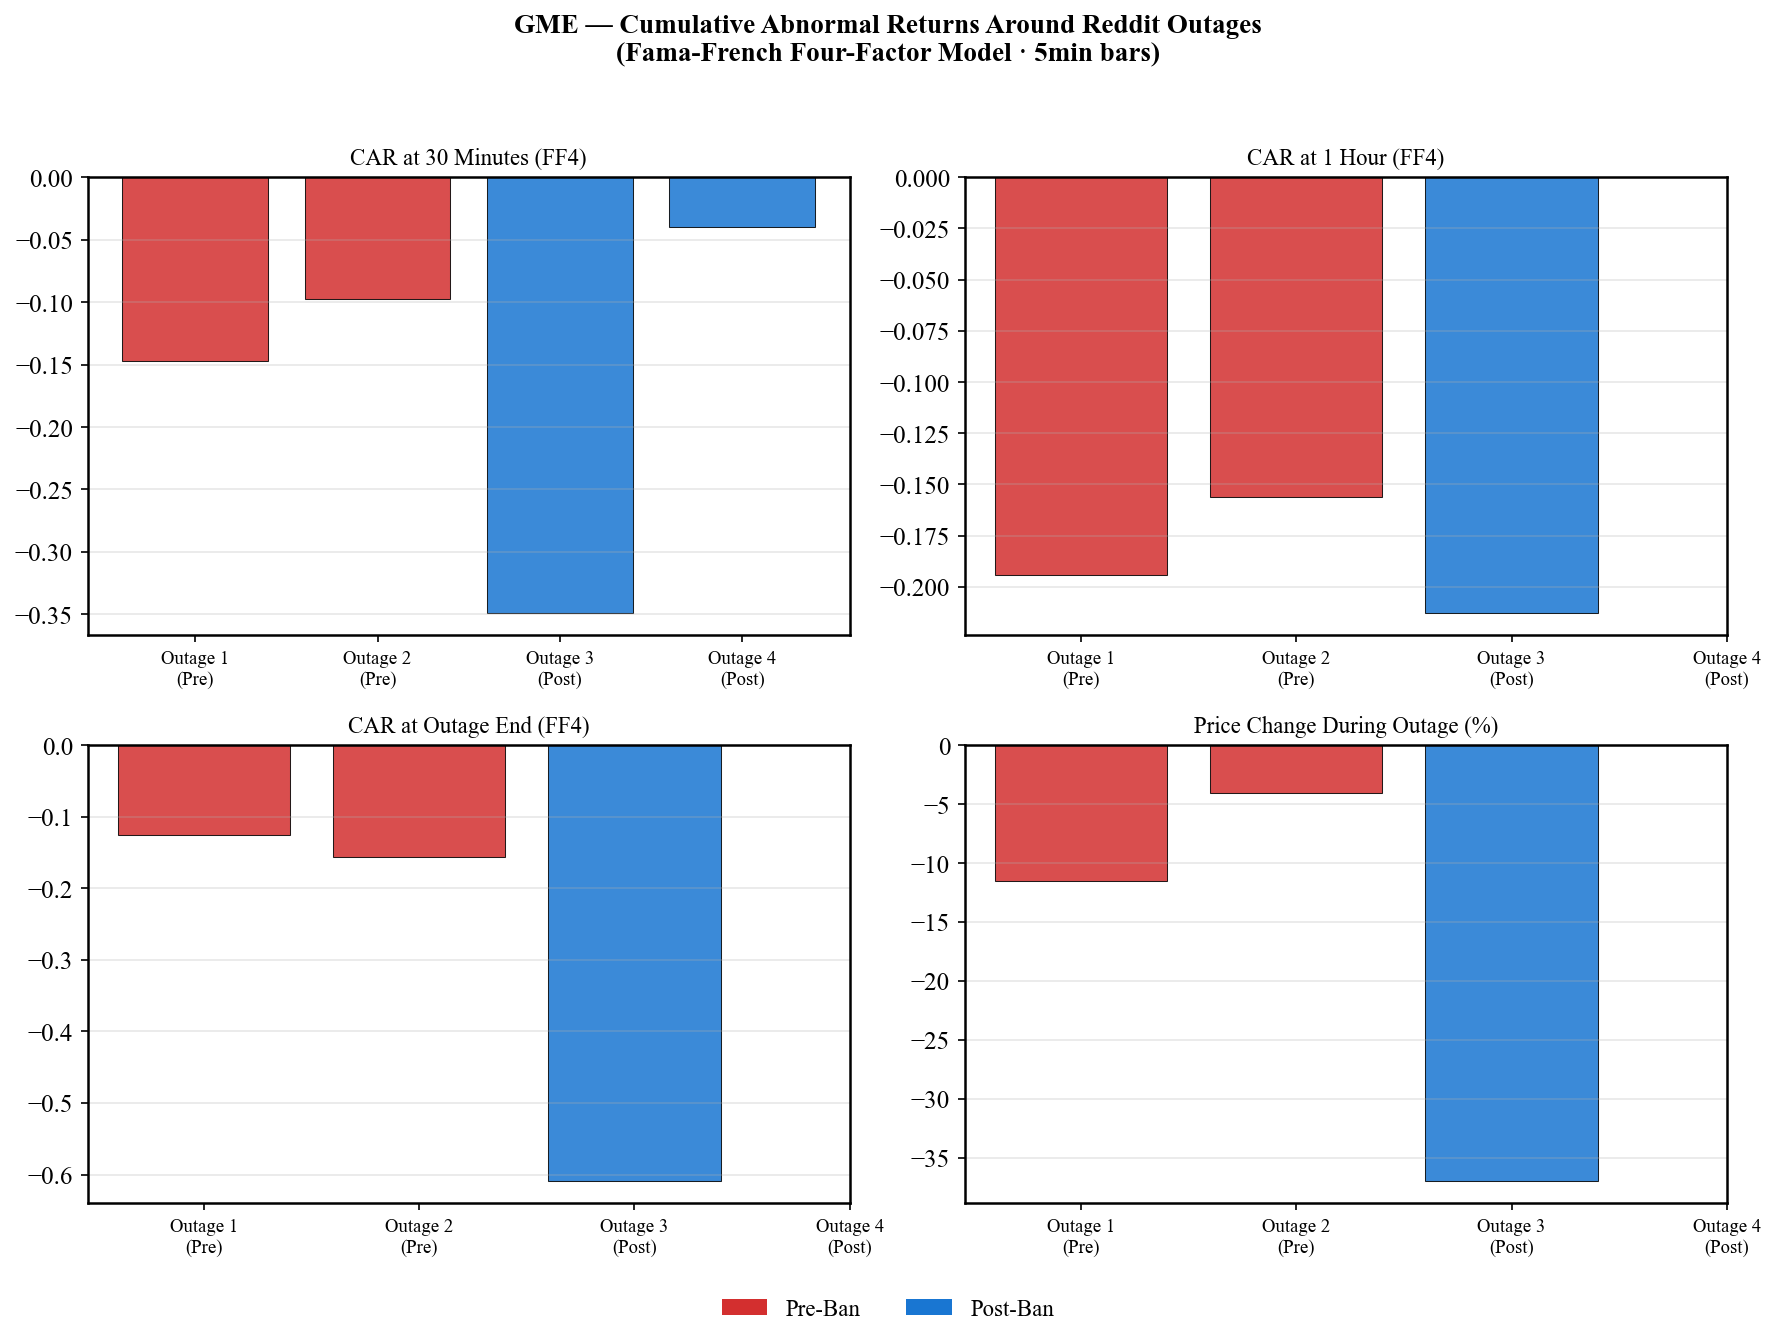

  Saved: output/multi_freq/figures/5min/gme/car_comparison_5min.png


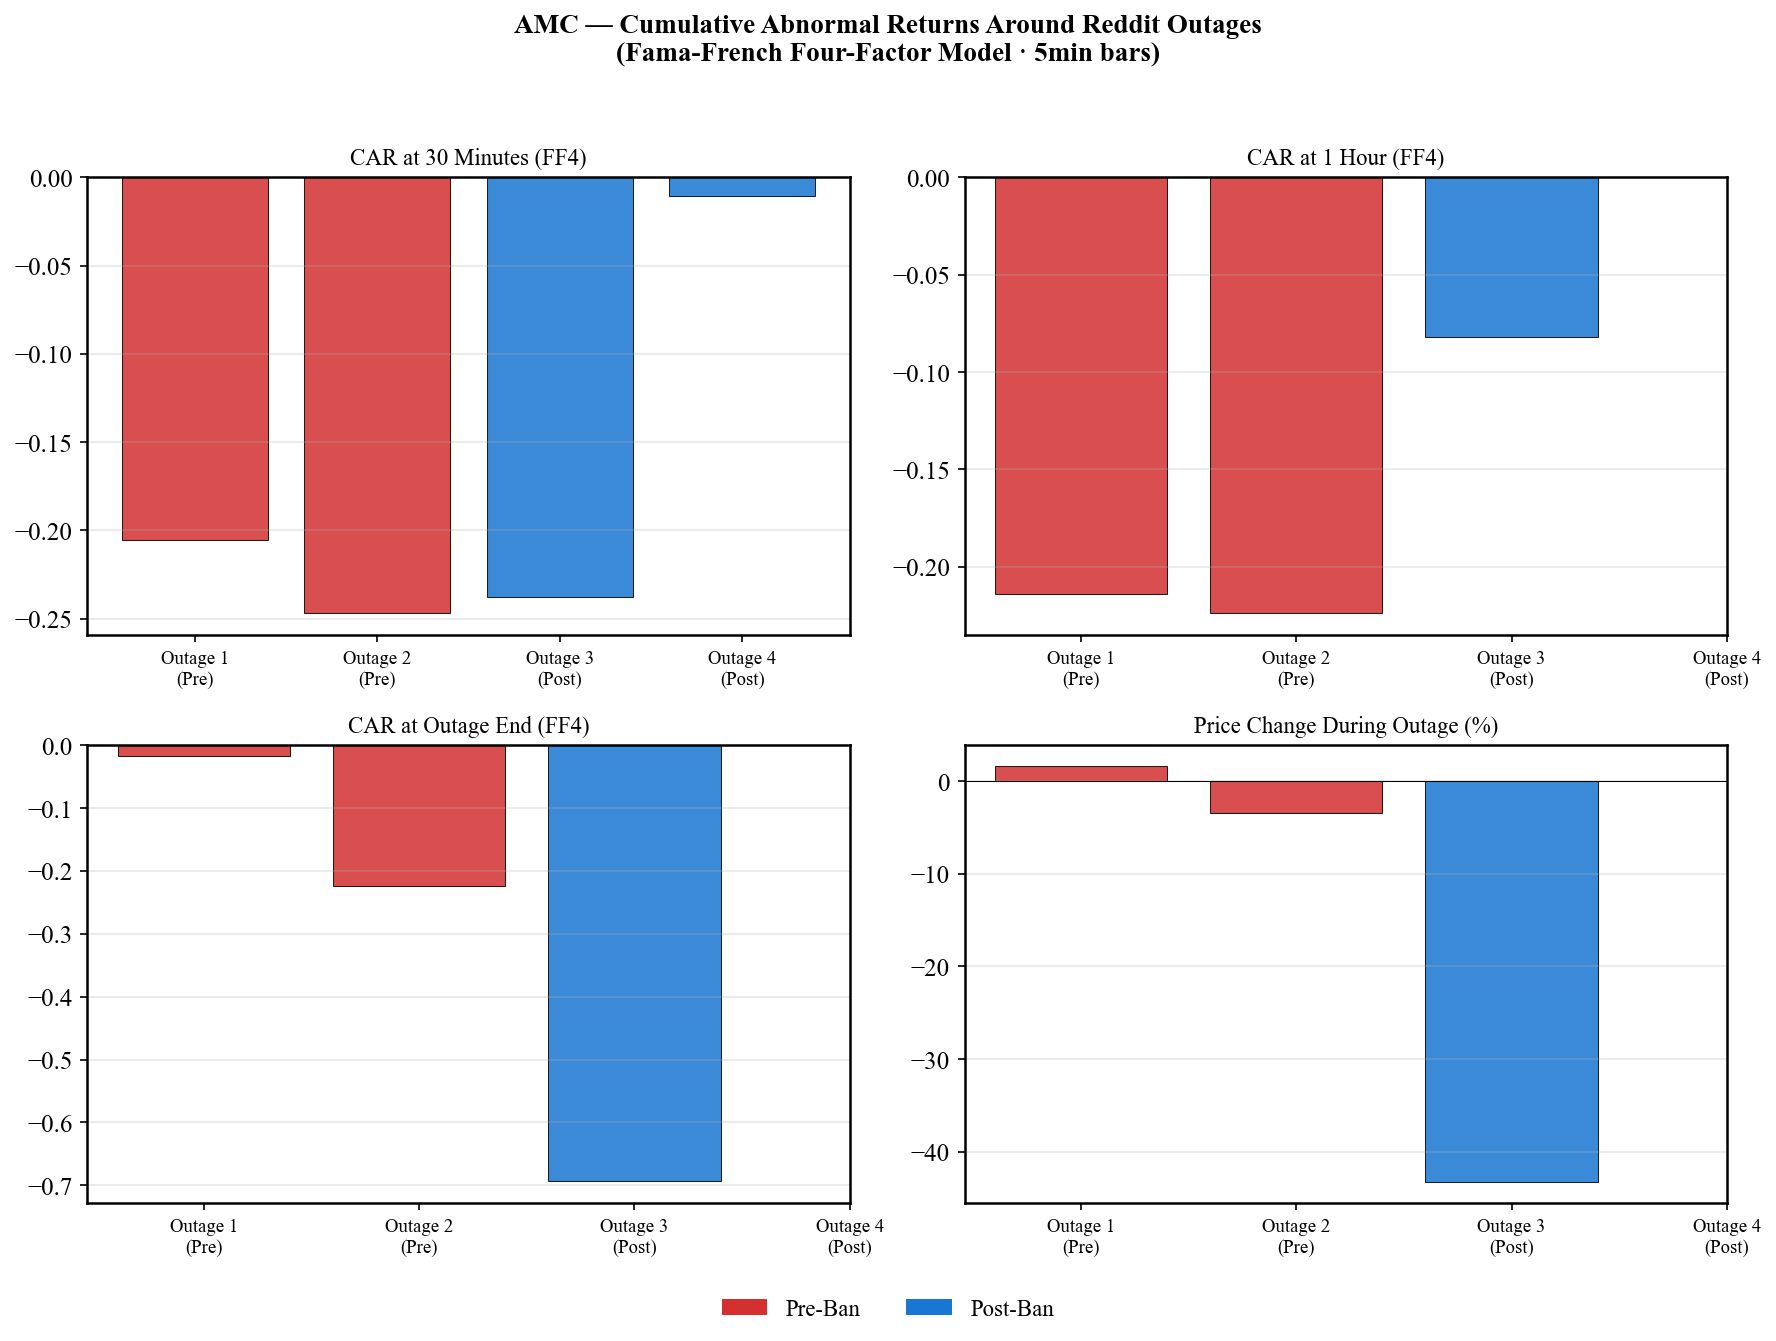

  Saved: output/multi_freq/figures/5min/amc/car_comparison_5min.png


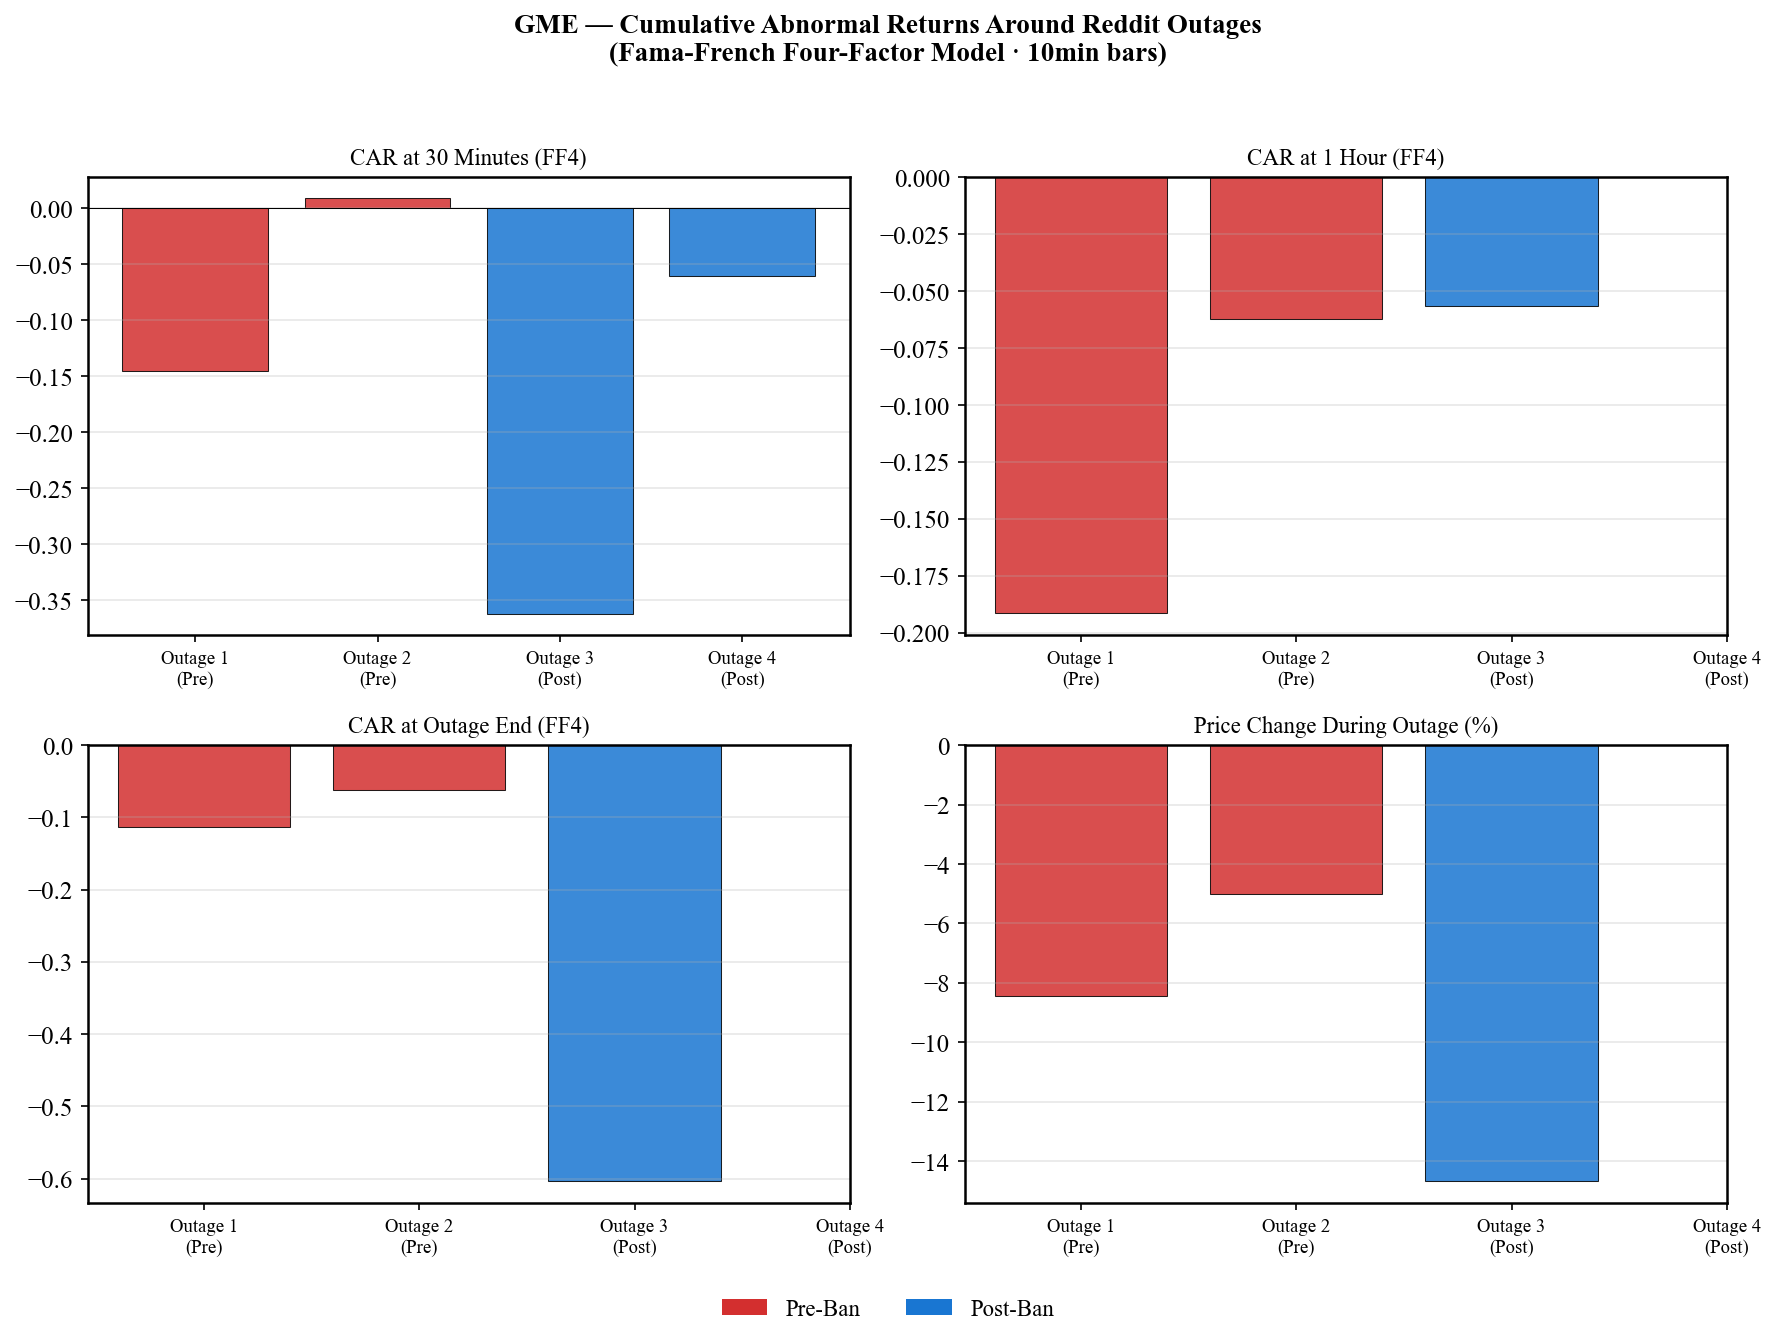

  Saved: output/multi_freq/figures/10min/gme/car_comparison_10min.png


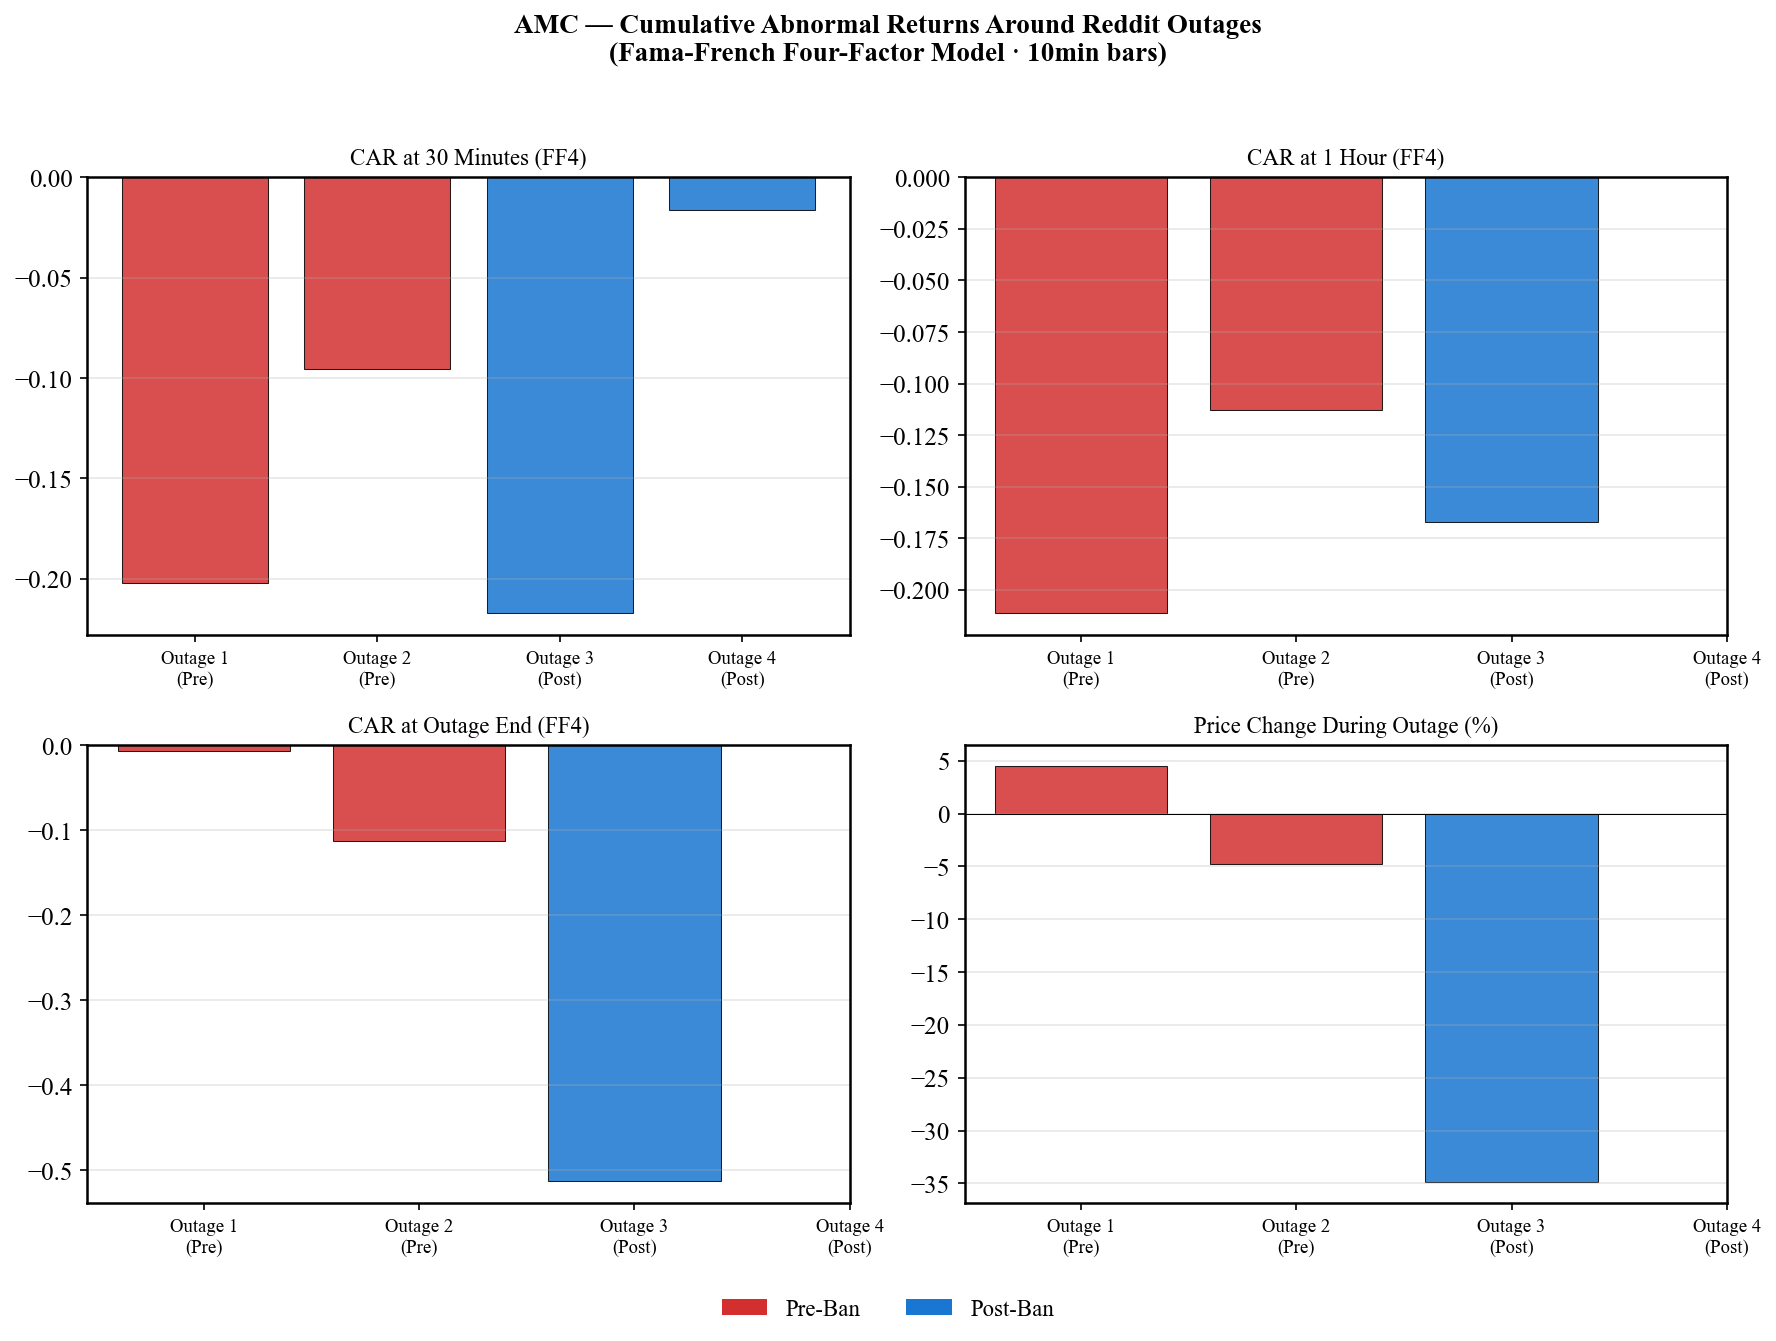

  Saved: output/multi_freq/figures/10min/amc/car_comparison_10min.png


In [6]:
def plot_car_comparison(event_results, symbol, freq_name):
    """2×2 bar chart: CAR at 30min, 1h, outage end, and price change."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(
        f"{symbol} — Cumulative Abnormal Returns Around Reddit Outages\n"
        f"(Fama-French Four-Factor Model · {freq_name} bars)",
        fontsize=13, fontweight="bold"
    )

    metrics = [
        ("CAR_30min_ff4",  "CAR at 30 Minutes (FF4)"),
        ("CAR_1h_ff4",     "CAR at 1 Hour (FF4)"),
        ("CAR_end_ff4",    "CAR at Outage End (FF4)"),
        ("price_change_pct", "Price Change During Outage (%)"),
    ]

    for ax, (key, title) in zip(axes.flat, metrics):
        names  = [r["event_name"] for r in event_results]
        values = [r[key] for r in event_results]
        colors = [PRE_BAN_COLOR if r["pre_ban"] else POST_BAN_COLOR
                  for r in event_results]

        ax.bar(range(len(names)), values, color=colors, alpha=0.85,
               edgecolor="black", linewidth=0.5)
        ax.set_title(title, fontsize=11)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(
            [n.replace(" (Pre-Ban)", "\n(Pre)").replace(" (Post-Ban)", "\n(Post)")
             for n in names],
            fontsize=9
        )
        ax.axhline(0, color="black", linewidth=0.5)
        ax.grid(axis="y", alpha=0.3)

    legend_elements = [
        Patch(facecolor=PRE_BAN_COLOR,  label="Pre-Ban"),
        Patch(facecolor=POST_BAN_COLOR, label="Post-Ban"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
               fontsize=11, frameon=False)

    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    out_path = FIG_BASE / freq_name / symbol.lower() / f"car_comparison_{freq_name}.png"
    fig.savefig(out_path)
    plt.show()
    print(f"  Saved: {out_path.relative_to(pathlib.Path.cwd())}")


for freq in FREQS:
    for sym in ["GME", "AMC"]:
        plot_car_comparison(all_results[freq][sym], sym, freq)

---
## 7. Cross-Frequency CAR Comparison

Side-by-side bars showing how CAR at outage end changes across 1-min, 5-min, and 10-min
bar frequencies. Load 1-min results from the existing FF4 notebook CSV for comparison.

1-min FF4 results loaded from existing CSV.


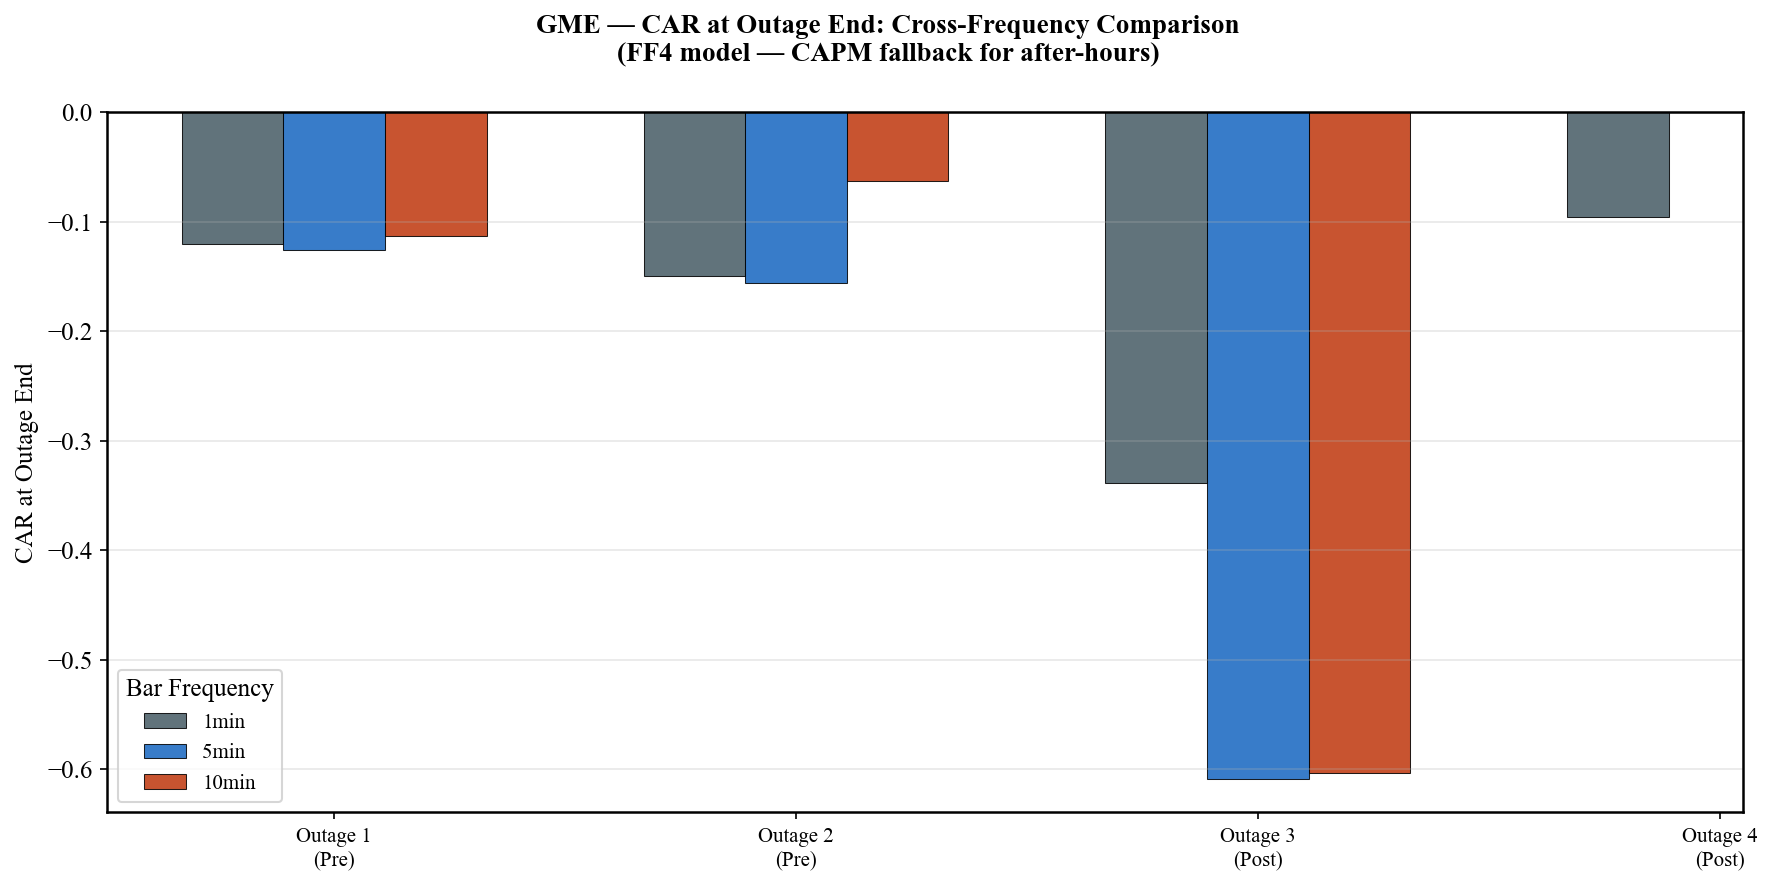

  Saved: output/multi_freq/figures/cross_freq_comparison_gme.png


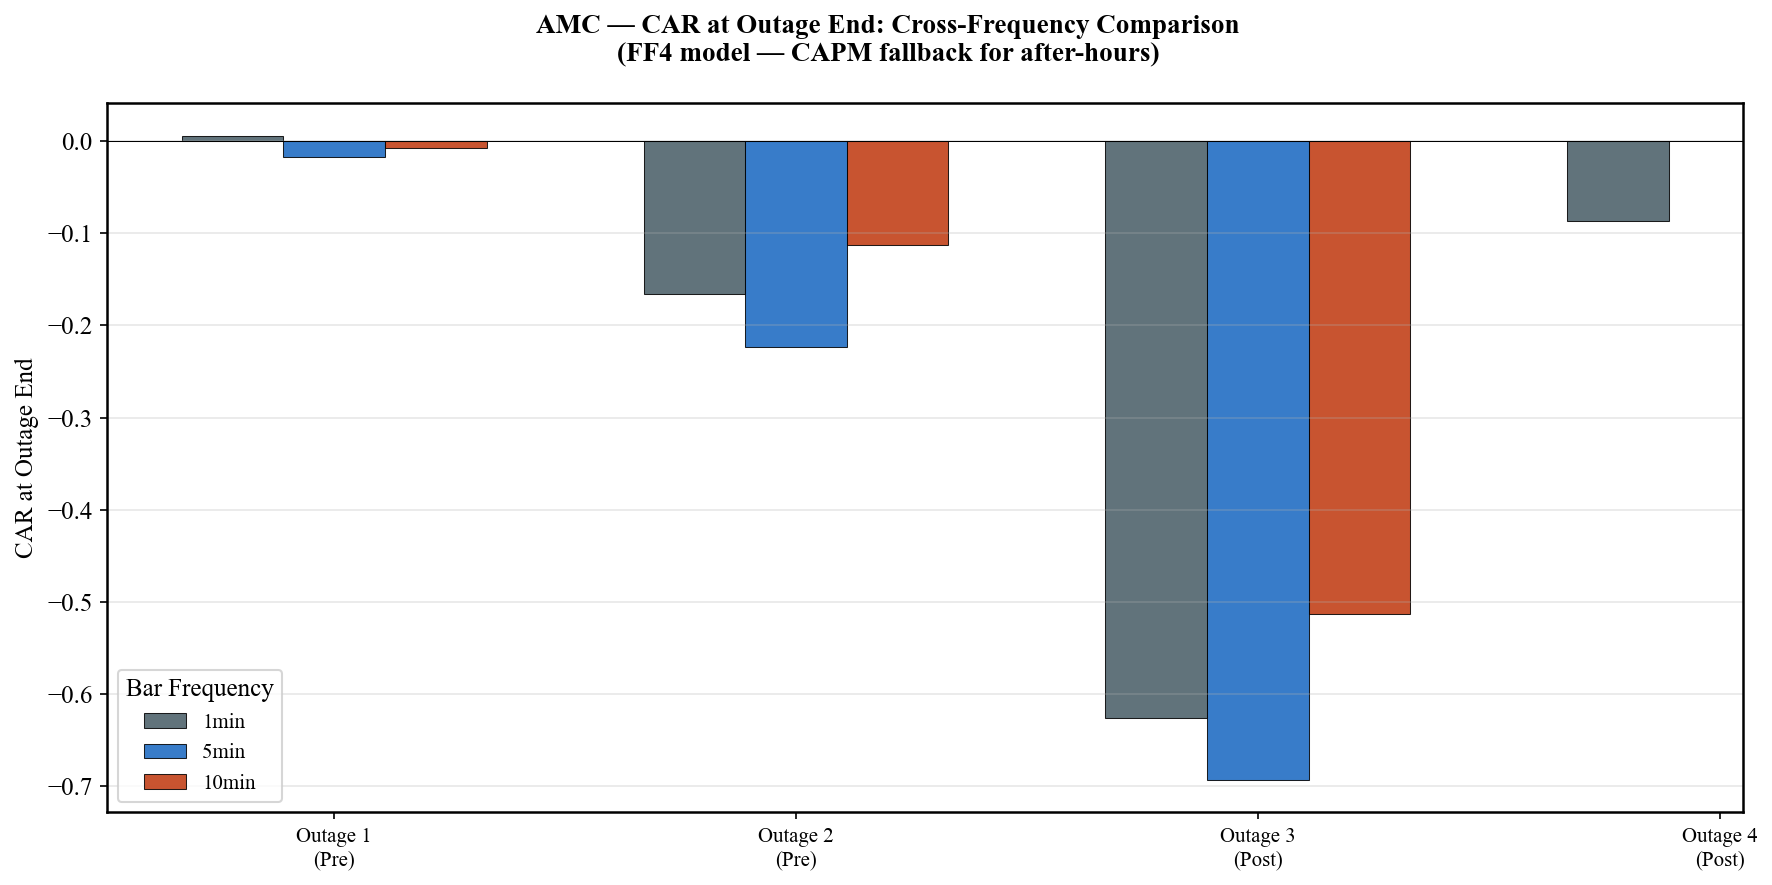

  Saved: output/multi_freq/figures/cross_freq_comparison_amc.png


In [7]:
# Load existing 1-min FF4 results for comparison
ff4_1min_path = pathlib.Path.cwd() / "output" / "ff4" / "car_results_ff4.csv"
has_1min = ff4_1min_path.exists()

if has_1min:
    ff4_1min = pd.read_csv(ff4_1min_path)
    # Normalise column names to match our structure
    ff4_1min = ff4_1min.rename(columns={"CAR @End": "CAR_end_ff4", "Stock": "Stock", "Event": "event_name"})
    print("1-min FF4 results loaded from existing CSV.")
else:
    print("1-min FF4 CSV not found — cross-frequency plot will show 5-min and 10-min only.")


def plot_cross_freq(symbol):
    """Grouped bar chart: CAR at outage end for each event across frequencies."""
    freq_colors = {"1min": "#455A64", "5min": "#1565C0", "10min": "#BF360C"}

    event_names = [e["name"] for e in OUTAGE_EVENTS]
    x = np.arange(len(event_names))
    n_freqs = (3 if has_1min else 2)
    width = 0.22

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(
        f"{symbol} — CAR at Outage End: Cross-Frequency Comparison\n"
        f"(FF4 model — CAPM fallback for after-hours)",
        fontsize=13, fontweight="bold"
    )

    plot_freqs = []
    if has_1min:
        sym_rows = ff4_1min[ff4_1min["Stock"] == symbol]
        cars_1min = []
        for evt in OUTAGE_EVENTS:
            row = sym_rows[sym_rows["event_name"] == evt["name"]]
            cars_1min.append(row["CAR_end_ff4"].values[0] if len(row) else np.nan)
        plot_freqs.append(("1min", cars_1min))

    for freq in FREQS:
        cars = [r["CAR_end_ff4"] for r in all_results[freq][symbol]]
        plot_freqs.append((freq, cars))

    offsets = np.linspace(-width * (len(plot_freqs) - 1) / 2,
                          width * (len(plot_freqs) - 1) / 2,
                          len(plot_freqs))

    for (freq_name, cars), offset in zip(plot_freqs, offsets):
        ax.bar(x + offset, cars, width, label=freq_name,
               color=freq_colors[freq_name], alpha=0.85,
               edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [n.replace(" (Pre-Ban)", "\n(Pre)").replace(" (Post-Ban)", "\n(Post)")
         for n in event_names],
        fontsize=10
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("CAR at Outage End")
    ax.legend(title="Bar Frequency", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    out_path = FIG_BASE / f"cross_freq_comparison_{symbol.lower()}.png"
    fig.savefig(out_path)
    plt.show()
    print(f"  Saved: {out_path.relative_to(pathlib.Path.cwd())}")


plot_cross_freq("GME")
plot_cross_freq("AMC")

---
## 8. Pre-Ban vs Post-Ban Summary

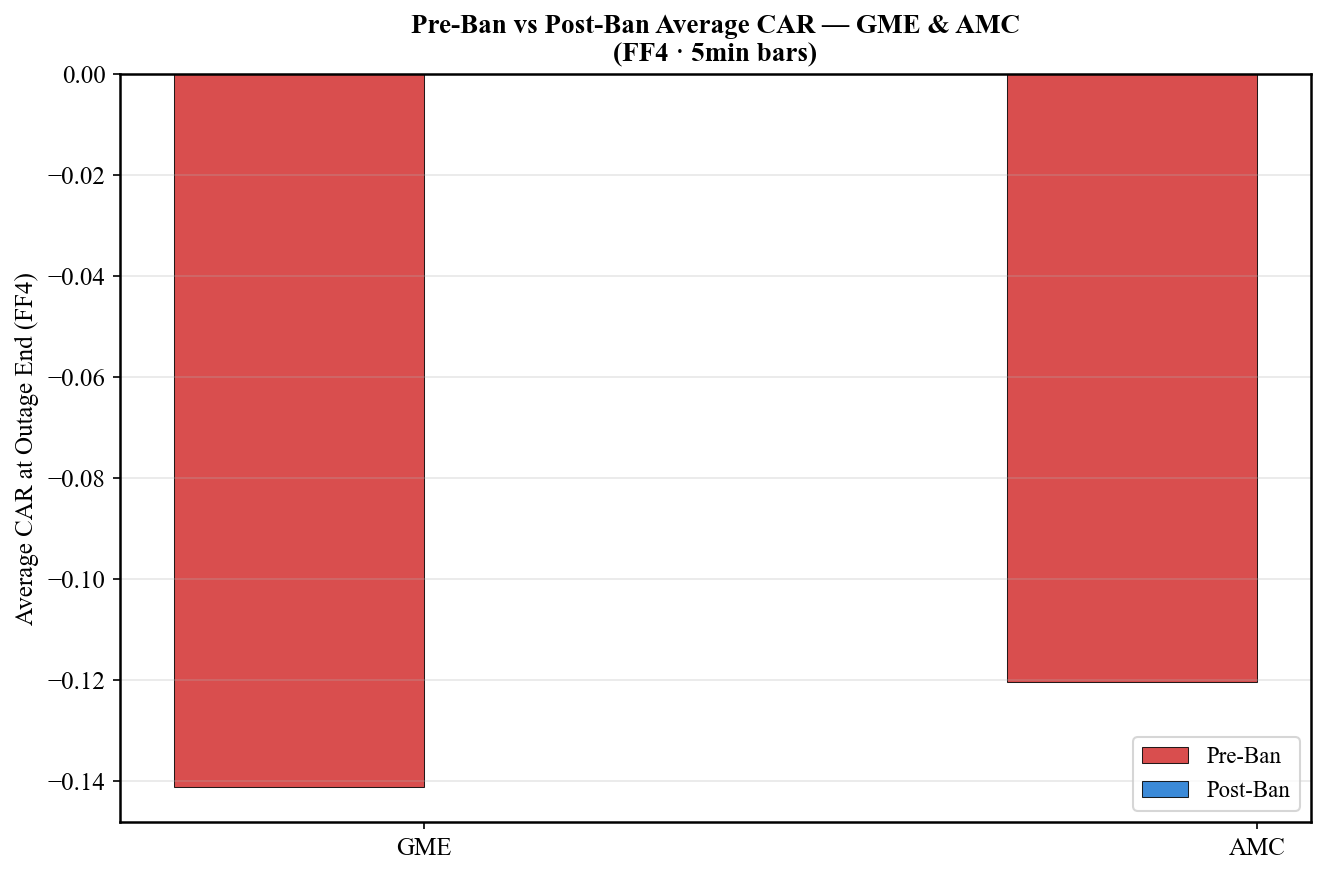

  Saved: output/multi_freq/figures/5min/pre_vs_post_ban_summary_5min.png


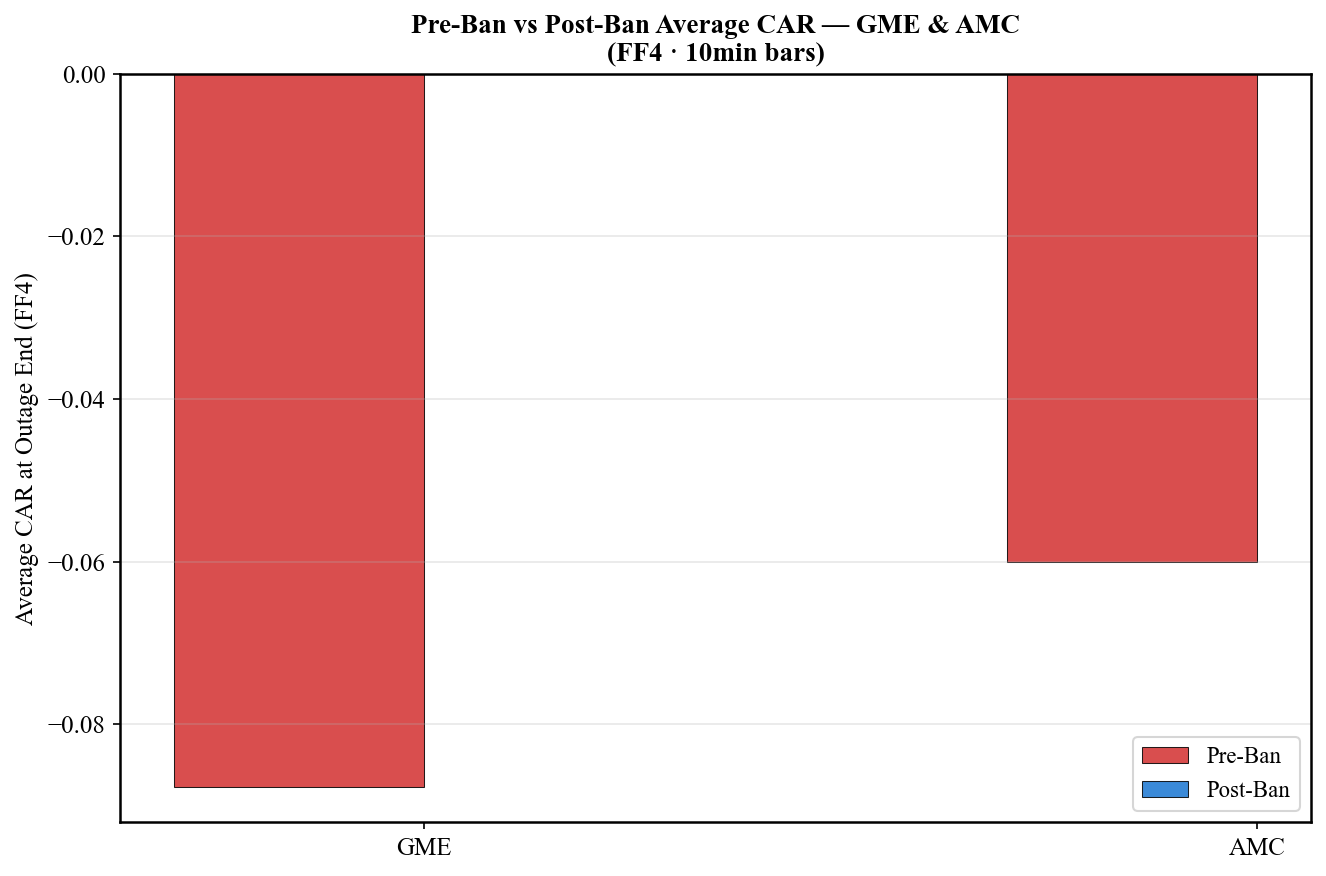

  Saved: output/multi_freq/figures/10min/pre_vs_post_ban_summary_10min.png


In [8]:
def plot_pre_post_summary(all_results, freq_name):
    """Grouped bar chart: average pre-ban vs post-ban CAR for GME and AMC."""
    fig, ax = plt.subplots(figsize=(9, 6))

    symbols = ["GME", "AMC"]
    x = np.arange(len(symbols))
    width = 0.3

    for i, (label, is_pre) in enumerate([("Pre-Ban", True), ("Post-Ban", False)]):
        means = []
        for sym in symbols:
            cars = [r["CAR_end_ff4"] for r in all_results[sym] if r["pre_ban"] == is_pre]
            means.append(np.mean(cars) if cars else 0)
        color = PRE_BAN_COLOR if is_pre else POST_BAN_COLOR
        ax.bar(x + i * width - width / 2, means, width, label=label,
               color=color, alpha=0.85, edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(symbols, fontsize=12)
    ax.set_ylabel("Average CAR at Outage End (FF4)")
    ax.set_title(
        f"Pre-Ban vs Post-Ban Average CAR — GME & AMC\n"
        f"(FF4 · {freq_name} bars)",
        fontsize=13, fontweight="bold"
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    out_path = FIG_BASE / freq_name / f"pre_vs_post_ban_summary_{freq_name}.png"
    fig.savefig(out_path)
    plt.show()
    print(f"  Saved: {out_path.relative_to(pathlib.Path.cwd())}")


for freq in FREQS:
    plot_pre_post_summary(all_results[freq], freq)

---
## 9. Final Summary

In [9]:
for freq in FREQS:
    print(f"\n{'='*70}")
    print(f"  SUMMARY @ {freq} — FF4 CAR at Outage End")
    print(f"{'='*70}")

    for sym in ["GME", "AMC"]:
        results   = all_results[freq][sym]
        pre_cars  = [r["CAR_end_ff4"] for r in results if r["pre_ban"]]
        post_cars = [r["CAR_end_ff4"] for r in results if not r["pre_ban"]]

        print(f"\n  {sym}:")
        print(f"    Pre-ban  avg CAR:  {np.mean(pre_cars):+.4f}")
        print(f"    Post-ban avg CAR:  {np.mean(post_cars):+.4f}")
        print(f"    Difference:        {np.mean(post_cars) - np.mean(pre_cars):+.4f}")
        print(f"\n    Event detail:")
        for r in results:
            period  = "Pre " if r["pre_ban"] else "Post"
            ff_note = f"[FF4 bars: {r['n_ff4_bars']}/{r['n_total_bars']}]"
            print(f"      [{period}] {r['event_name']:<28}  "
                  f"CAR={r['CAR_end_ff4']:+.4f}  "
                  f"Price={r['price_change_pct']:+.2f}%  {ff_note}")

print(f"\nAll figures saved to: {FIG_BASE}")


  SUMMARY @ 5min — FF4 CAR at Outage End

  GME:
    Pre-ban  avg CAR:  -0.1412
    Post-ban avg CAR:  +nan
    Difference:        +nan

    Event detail:
      [Pre ] Outage 1 (Pre-Ban)            CAR=-0.1262  Price=-11.49%  [FF4 bars: 27/27]
      [Pre ] Outage 2 (Pre-Ban)            CAR=-0.1562  Price=-4.08%  [FF4 bars: 0/12]
      [Post] Outage 3 (Post-Ban)           CAR=-0.6092  Price=-36.99%  [FF4 bars: 17/26]
      [Post] Outage 4 (Post-Ban)           CAR=+nan  Price=+nan%  [FF4 bars: 0/23]

  AMC:
    Pre-ban  avg CAR:  -0.1204
    Post-ban avg CAR:  +nan
    Difference:        +nan

    Event detail:
      [Pre ] Outage 1 (Pre-Ban)            CAR=-0.0169  Price=+1.63%  [FF4 bars: 27/27]
      [Pre ] Outage 2 (Pre-Ban)            CAR=-0.2239  Price=-3.40%  [FF4 bars: 0/12]
      [Post] Outage 3 (Post-Ban)           CAR=-0.6932  Price=-43.25%  [FF4 bars: 17/26]
      [Post] Outage 4 (Post-Ban)           CAR=+nan  Price=+nan%  [FF4 bars: 0/23]

  SUMMARY @ 10min — FF4 CAR at Out

---
## 10. Recovery Analyses (CAR Anchored at Outage End)

For each outage, compute CARs starting **at the moment the outage ends** and tracked at
+30 min, +1 hr, and +2 hr. CAR is normalised to 0 at the outage end timestamp.

Sigma is estimated from the FF4 model residuals (AR_ff4) over the estimation window
`[ESTIMATION_END − 120 days, ESTIMATION_END]` at each bar frequency, and used to form
Patell-style t-statistics: `t = CAR / (σ · √n_bars)`.

> **Note:** Outage 4 (ends 21:00 ET Jan 28) has no stock data beyond 19:59 ET and is
> therefore excluded from the recovery table.

In [10]:
def compute_sigma(df, estimation_end, window_days=120):
    """
    Compute per-bar sigma (std of FF4 residuals) from the estimation window.
    Falls back to CAPM residuals if FF4 is unavailable.
    """
    est_start = estimation_end - timedelta(days=window_days)
    w = df.loc[est_start:estimation_end]
    ar_col = "AR_ff4" if "AR_ff4" in w.columns else "AR_capm"
    residuals = w[ar_col].dropna()
    return float(residuals.std()) if len(residuals) > 1 else np.nan


def calculate_recovery_car(df, event, sigma):
    """
    Compute CAR anchored at outage end for +30min, +1hr, +2hr windows.

    Uses AR_ff4 where available, falls back to AR_capm (same hybrid rule as
    the main event study). Returns None if no bars exist in the recovery window.
    """
    recovery_start = event["end"]
    recovery_end   = recovery_start + timedelta(hours=2)

    ed = df.loc[recovery_start:recovery_end].copy()
    if ed.empty:
        return None

    ff4_available   = ed["AR_ff4"].notna()
    ar_hybrid       = ed["AR_ff4"].where(ff4_available, ed["AR_capm"])
    ed["CAR_recov"] = ar_hybrid.cumsum()

    def car_at(target):
        mask = ed.index <= target
        return ed.loc[mask, "CAR_recov"].iloc[-1] if mask.any() else np.nan

    def t_stat(car, n):
        if np.isnan(car) or np.isnan(sigma) or sigma == 0 or n == 0:
            return np.nan
        return car / (sigma * np.sqrt(n))

    def sig_stars(t):
        if np.isnan(t):
            return ""
        p = 2 * (1 - __import__("scipy").stats.norm.cdf(abs(t)))
        if p < 0.01:  return "***"
        if p < 0.05:  return "**"
        if p < 0.10:  return "*"
        return ""

    t30  = recovery_start + timedelta(minutes=30)
    t1h  = recovery_start + timedelta(hours=1)
    t2h  = recovery_start + timedelta(hours=2)

    car_30  = car_at(t30)
    car_1h  = car_at(t1h)
    car_2h  = car_at(t2h)

    n30  = int(ed.loc[recovery_start:t30].notna().any(axis=1).sum())
    n1h  = int(ed.loc[recovery_start:t1h].notna().any(axis=1).sum())
    n2h  = int(ed.loc[recovery_start:t2h].notna().any(axis=1).sum())

    ts_30  = t_stat(car_30, n30)
    ts_1h  = t_stat(car_1h, n1h)
    ts_2h  = t_stat(car_2h, n2h)

    n_ff4  = int(ff4_available.sum())
    n_tot  = len(ed)

    return {
        "event_name":    event["name"],
        "recovery_start": recovery_start,
        "pre_ban":       event["pre_ban"],
        "CAR @+30min":   car_30,
        "t (@30m)":      ts_30,
        "CAR @+1h":      car_1h,
        "t (@1h)":       ts_1h,
        "CAR @+2h":      car_2h,
        "t (@2h)":       ts_2h,
        "Sig":           sig_stars(ts_2h),
        "FF Bars / Total": f"{n_ff4}/{n_tot}",
        "event_data":    ed,
    }


# ── Run recovery analysis ──────────────────────────────────────────────────────
recovery_results = {}

for freq in FREQS:
    recovery_results[freq] = {}
    for sym in ["GME", "AMC"]:
        df = data[freq][sym]
        sigma = compute_sigma(df, ESTIMATION_END)

        rows = []
        for evt in OUTAGE_EVENTS:
            r = calculate_recovery_car(df, evt, sigma)
            if r is not None:
                rows.append(r)
        recovery_results[freq][sym] = rows

    # ── Print results table ────────────────────────────────────────────────────
    print(f"\n{'='*75}")
    print(f"  RECOVERY CARs @ {freq} (anchored at outage end)")
    print(f"{'='*75}")

    table_rows = []
    for sym in ["GME", "AMC"]:
        for r in recovery_results[freq][sym]:
            table_rows.append({
                "Stock":           sym,
                "Event":           r["event_name"],
                "Recovery Start":  r["recovery_start"].strftime("%Y-%m-%d %H:%M"),
                "CAR @+30min":     f"{r['CAR @+30min']:+.4f}" if not np.isnan(r["CAR @+30min"]) else "—",
                "CAR @+1h":        f"{r['CAR @+1h']:+.4f}"    if not np.isnan(r["CAR @+1h"])    else "—",
                "CAR @+2h":        f"{r['CAR @+2h']:+.4f}"    if not np.isnan(r["CAR @+2h"])    else "—",
                "t (@2h)":         f"{r['t (@2h)']:+.3f}"     if not np.isnan(r["t (@2h)"])     else "—",
                "Sig":             r["Sig"],
                "FF Bars / Total": r["FF Bars / Total"],
            })

    tdf = pd.DataFrame(table_rows)
    print(tdf.to_string(index=False))

print("\nRecovery analysis complete.")


  RECOVERY CARs @ 5min (anchored at outage end)
Stock               Event   Recovery Start CAR @+30min CAR @+1h CAR @+2h t (@2h) Sig FF Bars / Total
  GME  Outage 1 (Pre-Ban) 2021-01-27 13:40     -0.0396  -0.0696  +0.0263  +0.448               25/25
  GME  Outage 2 (Pre-Ban) 2021-01-27 17:01     +0.0266  -0.0062  -0.1685  -2.929 ***            0/24
  GME Outage 3 (Post-Ban) 2021-01-28 10:51     -0.9815  -0.4604  -0.3952  -6.871 ***           23/24
  GME Outage 4 (Post-Ban) 2021-01-28 21:00           —        —        —       —                0/25
  AMC  Outage 1 (Pre-Ban) 2021-01-27 13:40     +0.1486  +0.1387  +0.0964  +2.009  **           25/25
  AMC  Outage 2 (Pre-Ban) 2021-01-27 17:01     +0.0029  +0.0042  -0.2144  -4.561 ***            0/24
  AMC Outage 3 (Post-Ban) 2021-01-28 10:51     -0.6134  -0.2983  -0.1081  -2.300  **           24/24
  AMC Outage 4 (Post-Ban) 2021-01-28 21:00           —        —        —       —                0/25

  RECOVERY CARs @ 10min (anchored at outa

In [11]:
# ── Save recovery results to CSV (one file per frequency) ─────────────────────
for freq in FREQS:
    rows = []
    for sym in ["GME", "AMC"]:
        for r in recovery_results[freq][sym]:
            rows.append({
                "Stock":            sym,
                "Event":            r["event_name"],
                "Recovery Start":   r["recovery_start"],
                "CAR @+30min":      r["CAR @+30min"],
                "t (@30m)":         r["t (@30m)"],
                "CAR @+1h":         r["CAR @+1h"],
                "t (@1h)":          r["t (@1h)"],
                "CAR @+2h":         r["CAR @+2h"],
                "t (@2h)":          r["t (@2h)"],
                "Sig":              r["Sig"],
                "FF Bars / Total":  r["FF Bars / Total"],
            })
    if rows:
        out_path = OUTPUT_DIR / f"car_results_{freq}_recovery.csv"
        pd.DataFrame(rows).to_csv(out_path, index=False)
        print(f"Saved: {out_path}")

print("Recovery CSVs saved.")

Saved: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/multi_freq/car_results_5min_recovery.csv
Saved: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/multi_freq/car_results_10min_recovery.csv
Recovery CSVs saved.
